# Load the results and plot, save figs

In [1]:
import json

# --- Load PolyFit (formerly Chebyshev) data files ---
with open("ibm_cleveland_dd_sampled_mpsrun0_energy_dict.json", "r") as f:
    raw_data = json.load(f)
    ibm_cleveland_polyfit = {
        "energies": {k: v["energy"] for k, v in raw_data.items()},
        "counts": {k: v["count"] for k, v in raw_data.items()}
    }
    total = sum(ibm_cleveland_polyfit["counts"].values())
    ibm_cleveland_polyfit["probs"] = {k: c / total for k, c in ibm_cleveland_polyfit["counts"].items()}

with open("ibm_kingston_dd_sampled_mpsrun0_energy_dict.json", "r") as f:
    raw_data = json.load(f)
    ibm_kingston_polyfit = {
        "energies": {k: v["energy"] for k, v in raw_data.items()},
        "counts": {k: v["count"] for k, v in raw_data.items()}
    }
    total = sum(ibm_kingston_polyfit["counts"].values())
    ibm_kingston_polyfit["probs"] = {k: c / total for k, c in ibm_kingston_polyfit["counts"].items()}

# --- Load VQEC data files ---
with open("cleveland_vqec_sampled_dd_energy_dict.json", "r") as f:
    raw_data = json.load(f)
    ibm_cleveland_vqec = {
        "energies": {k: v["energy"] for k, v in raw_data.items()},
        "counts": {k: v["count"] for k, v in raw_data.items()}
    }
    total = sum(ibm_cleveland_vqec["counts"].values())
    ibm_cleveland_vqec["probs"] = {k: c / total for k, c in ibm_cleveland_vqec["counts"].items()}

with open("kingston_vqec_sampled_dd_energy_dict.json", "r") as f:
    raw_data = json.load(f)
    ibm_kingston_vqec = {
        "energies": {k: v["energy"] for k, v in raw_data.items()},
        "counts": {k: v["count"] for k, v in raw_data.items()}
    }
    total = sum(ibm_kingston_vqec["counts"].values())
    ibm_kingston_vqec["probs"] = {k: c / total for k, c in ibm_kingston_vqec["counts"].items()}

# --- Load MPS simulation results ---
with open("mpsrun0_polyfit_sampled_energy_dict.json", "r") as f:
    raw_data = json.load(f)
    mps_polyfit = {
        "energies": {k: v["energy"] for k, v in raw_data.items()},
        "counts": {k: v["count"] for k, v in raw_data.items()}
    }
    total = sum(mps_polyfit["counts"].values())
    mps_polyfit["probs"] = {k: c / total for k, c in mps_polyfit["counts"].items()}

with open("mps_vqec_sampled_energy_dict.json", "r") as f:
    raw_data = json.load(f)
    mps_vqec = {
        "energies": {k: v["energy"] for k, v in raw_data.items()},
        "counts": {k: v["count"] for k, v in raw_data.items()}
    }
    total = sum(mps_vqec["counts"].values())
    mps_vqec["probs"] = {k: c / total for k, c in mps_vqec["counts"].items()}


# ibm_cleveland plots for polyfit

In [6]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib as mpl
import numpy as np
plt.style.use(['science'])

/var/folders/f0/3f43g55s7jj8xnhyp1dq2nfh0000gn/T/ipykernel_97256/1150990738.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y * 100)}" for y in ax.get_yticks()], fontsize=16)
/var/folders/f0/3f43g55s7jj8xnhyp1dq2nfh0000gn/T/ipykernel_97256/1150990738.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  inset_ax.set_yticklabels([f"{(y * 100)}" for y in inset_ax.get_yticks()], fontsize=14)


[-30.570074742040894, -30.54929210142344, -30.547511434593567, -30.45217797019747, -30.451576447537764, -30.43299873057301, -30.431009378202493, -30.425689245042722, -30.32881652524862, -30.252008372907074, -30.135166798458588, -30.12959205150306, -30.129001685658622, -29.565910765101492, -29.563373108996682, -29.36283131197908, -29.25617834014716, -29.141839946329416, -29.139998369934172, -29.138615541552223]


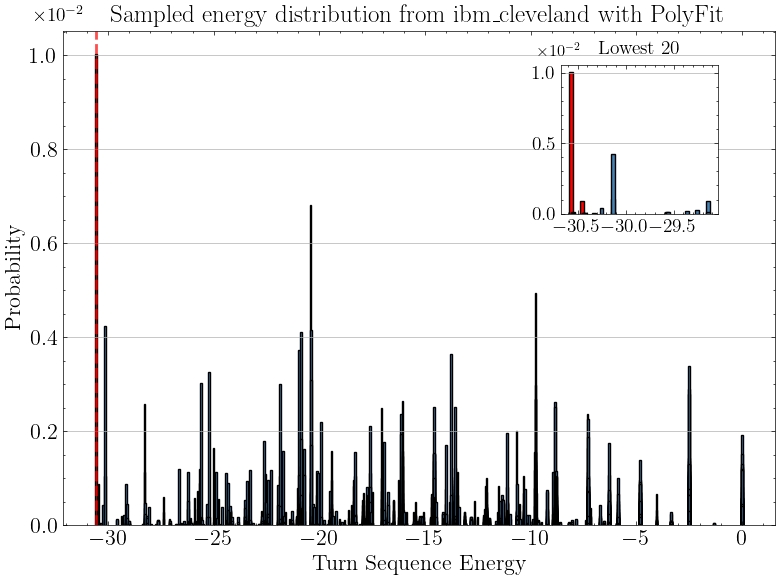

In [61]:
# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = ibm_cleveland_polyfit
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Adjustable bar width ---
bar_width = 0.08

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(x_vals, y_vals, width=bar_width, color=bar_colors, align='center', edgecolor='black')

ax.set_xlabel("Turn Sequence Energy", fontsize=16)
ax.set_ylabel("Probability", fontsize=16)
ax.set_title("Sampled energy distribution from ibm_cleveland with PolyFit", fontsize=18, fontweight='bold')
ax.tick_params(axis='x', labelsize=16, which='major', direction='in', top=True)
ax.tick_params(axis='y', labelsize=16, which='major', direction='in', right=True)
# Add x10^-2 to y-axis label
# ax.set_yticks(ax.get_yticks())  # Ensure y-ticks are set
ax.set_yticklabels([f"{(y * 100)}" for y in ax.get_yticks()], fontsize=16)
ax.text(-0.04, 1.05, r"$\times 10^{-2}$", transform=ax.transAxes, fontsize=14, verticalalignment='top', color='black')
ax.grid(True, axis='y')

# --- Highlight lowest energy ---
lowest_energy = min(neg_energies.values())
ax.axvline(x=lowest_energy, color='red', linestyle='--', linewidth=2, alpha=0.7)

# --- Inset plot (wider + shorter) ---
inset_ax = ax.inset_axes([0.70, 0.63, 0.22, 0.30])
full_sorted_turns = sorted(energies_raw.keys(), key=lambda t: energies_raw[t])
inset_x = [energies_raw[t] for t in full_sorted_turns[:20]]
inset_y = [probs_raw[t] for t in full_sorted_turns[:20]]
inset_colors = ['red' if t in top_cls_turns else 'steelblue' for t in full_sorted_turns[:20]]
print(inset_x)

bars_inset = inset_ax.bar(inset_x, inset_y, width=0.04, color=inset_colors, edgecolor='black')
inset_ax.set_title("Lowest 20", fontsize=14, y=1.02)
# inset_ax.set_ylabel("Probability", fontsize=14)
inset_ax.tick_params(axis='x', labelsize=14, which='major', direction='in', top=True)
inset_ax.tick_params(axis='y', labelsize=14, which='major', direction='in', right=True)
inset_ax.grid(True, axis='y')
inset_ax.set_yticklabels([f"{(y * 100)}" for y in inset_ax.get_yticks()], fontsize=14)
inset_ax.text(-0.15, 1.15, r"$\times 10^{-2}$", transform=inset_ax.transAxes, fontsize=12, verticalalignment='top', color='black')
inset_ax.set_xlim(min(inset_x) - 0.1, max(inset_x) + 0.1)

# --- Legend for inset ---
legend_handles = []
legend_labels = []
for bar, turn in zip(bars_inset, full_sorted_turns[:50]):
    if turn in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn)

# if legend_handles:
#     inset_ax.legend(
#         legend_handles,
#         legend_labels,
#         title="Top CLS Turns",
#         fontsize=14,
#         title_fontsize=12,
#         loc="center left",
#         bbox_to_anchor=(1, 0.5),  # right outside the inset, vertically centered
#         borderaxespad=0.5,
#         frameon=True
#     )

plt.tight_layout()

# --- Save (commented out) ---
# plt.savefig("ibm_cleveland_polyfit.pdf", dpi=400, bbox_inches='tight')
plt.show()


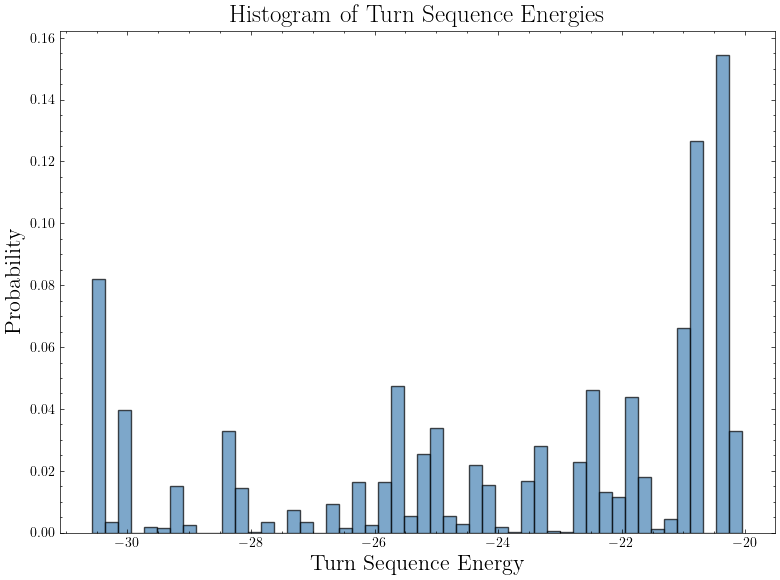

In [ ]:
# Try a histogram of the energies (not looking good...)
num_meas = 100_000

# --- Select dataset ---
data = ibm_cleveland_polyfit
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < -20]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
energies_to_plot = []
for t in sorted_turns:
    energies_to_plot.extend([neg_energies[t]] * int(num_meas * neg_probs[t]))

fig, ax = plt.subplots(figsize=(8, 6))
weights = np.ones_like(energies_to_plot) / len(energies_to_plot)  # Normalize the histogram
ax.hist(energies_to_plot, bins=50, color='steelblue', edgecolor='black', alpha=0.7, weights=weights)
ax.set_xlabel("Turn Sequence Energy", fontsize=16)
ax.set_ylabel("Probability", fontsize=16)
ax.set_title("Histogram of Turn Sequence Energies", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

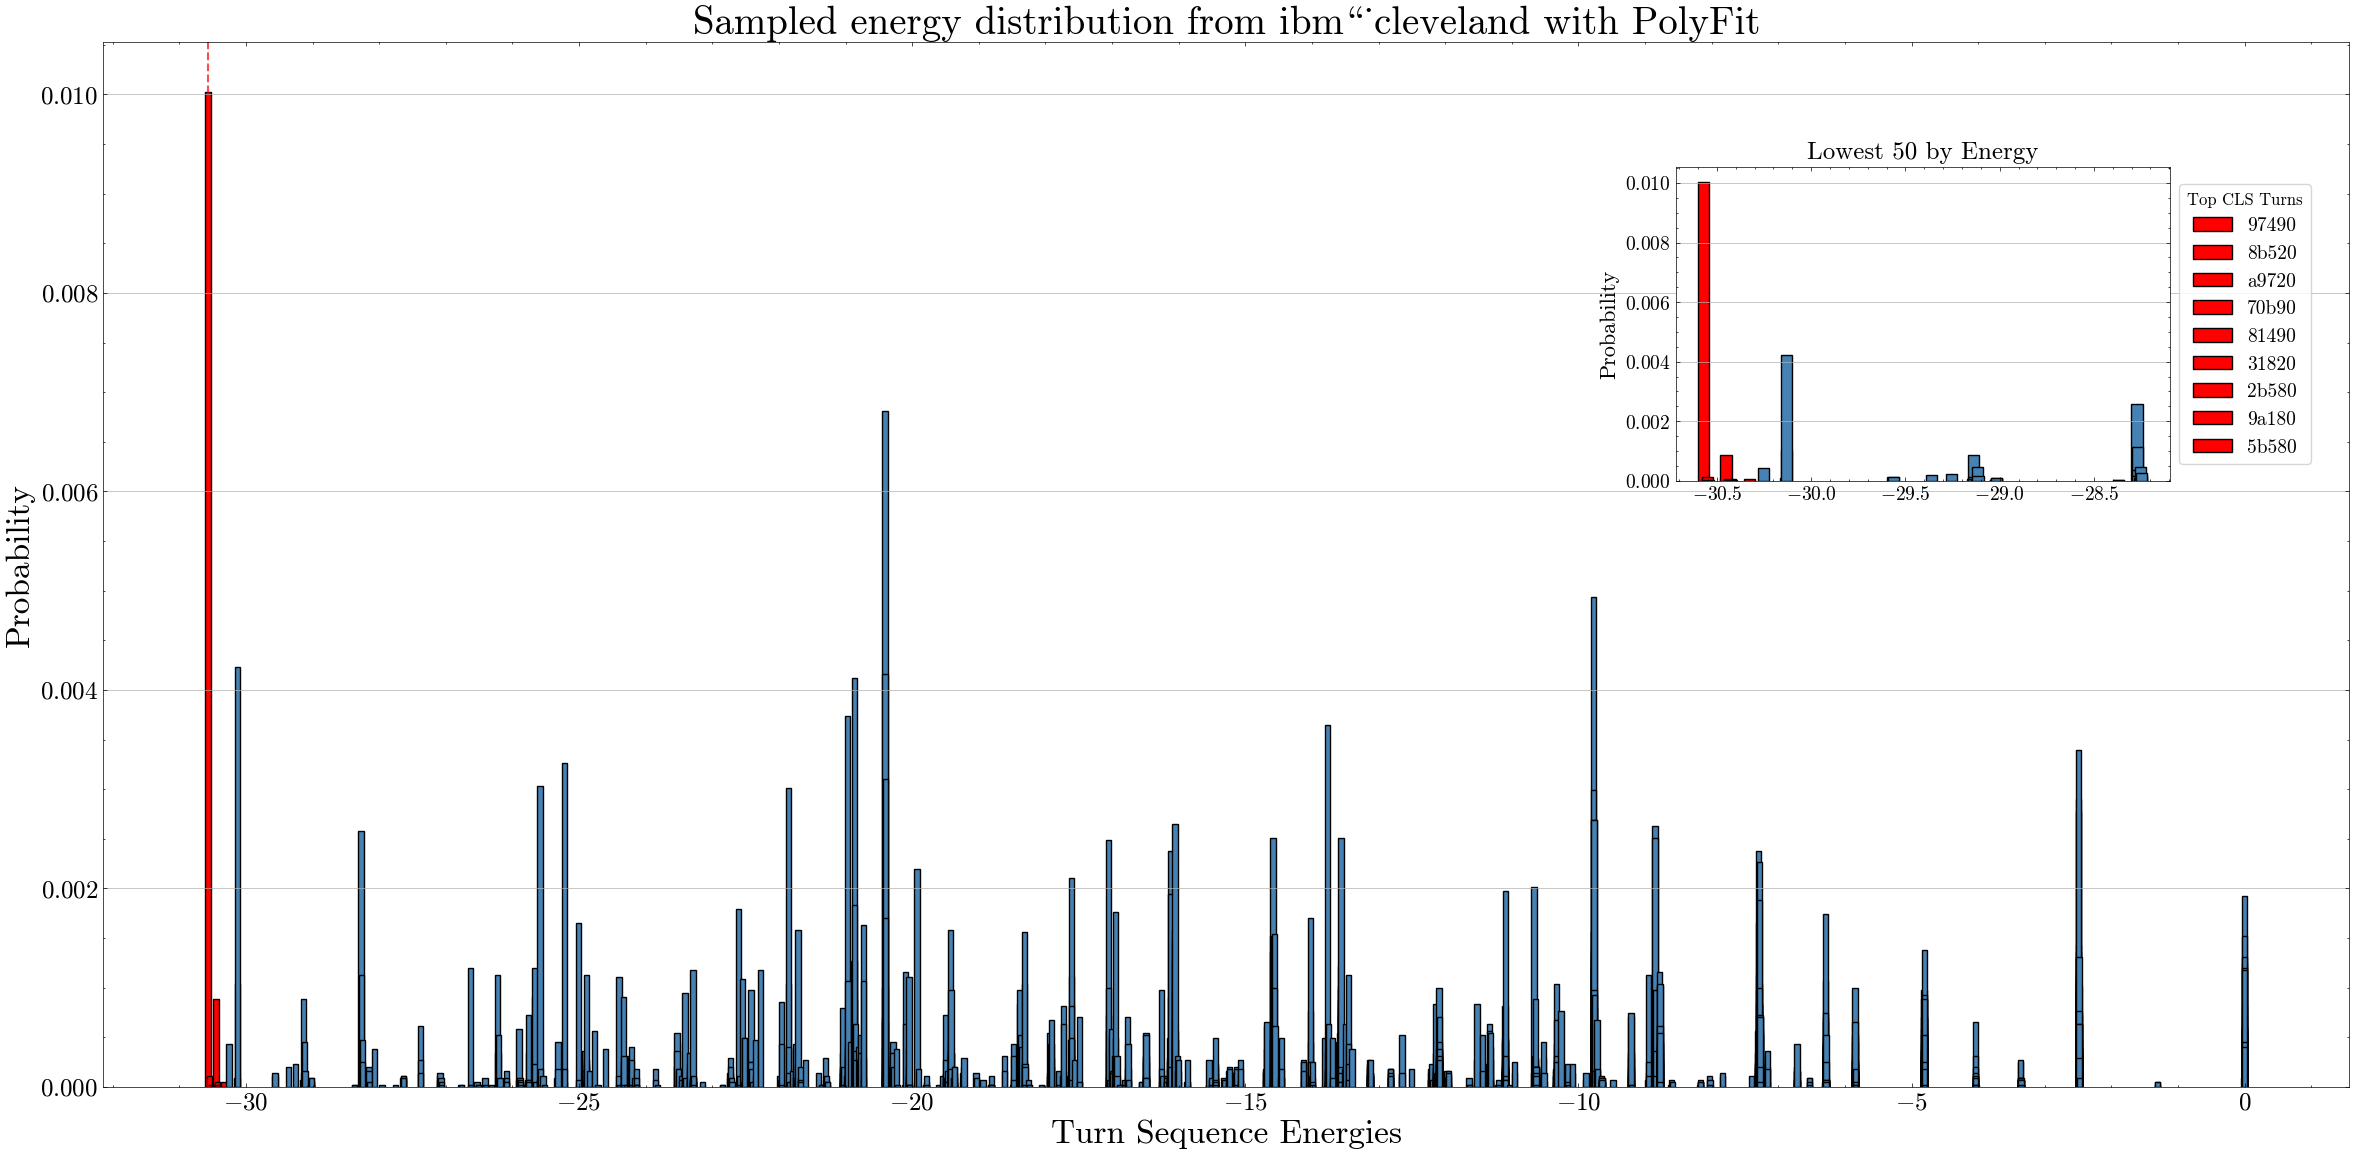

In [ ]:
# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = ibm_cleveland_polyfit
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Adjustable bar width ---
bar_width = 0.08

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=bar_width, color=bar_colors, align='center', edgecolor='black')

ax.set_xlabel("Turn Sequence Energies", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
ax.set_title("Sampled energy distribution from ibm\_cleveland with PolyFit", fontsize=28, fontweight='bold')
ax.tick_params(axis='x', labelsize=18, which='major', direction='in', top=True)
ax.tick_params(axis='y', labelsize=18, which='major', direction='in', right=True)
ax.grid(True, axis='y')

# --- Highlight lowest energy ---
lowest_energy = min(neg_energies.values())
ax.axvline(x=lowest_energy, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Inset plot (wider + shorter) ---
inset_ax = ax.inset_axes([0.70, 0.58, 0.22, 0.30])
full_sorted_turns = sorted(energies_raw.keys(), key=lambda t: energies_raw[t])
inset_x = [energies_raw[t] for t in full_sorted_turns[:50]]
inset_y = [probs_raw[t] for t in full_sorted_turns[:50]]
inset_colors = ['red' if t in top_cls_turns else 'steelblue' for t in full_sorted_turns[:50]]

bars_inset = inset_ax.bar(inset_x, inset_y, width=0.06, color=inset_colors, edgecolor='black')
inset_ax.set_title("Lowest 50 by Energy", fontsize=18)
inset_ax.set_ylabel("Probability", fontsize=16)
inset_ax.tick_params(axis='x', labelsize=14, which='major', direction='in', top=True)
inset_ax.tick_params(axis='y', labelsize=14, which='major', direction='in', right=True)
inset_ax.grid(True, axis='y')

# --- Legend for inset ---
legend_handles = []
legend_labels = []
for bar, turn in zip(bars_inset, full_sorted_turns[:50]):
    if turn in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn)

if legend_handles:
    inset_ax.legend(
        legend_handles,
        legend_labels,
        title="Top CLS Turns",
        fontsize=14,
        title_fontsize=12,
        loc="center left",
        bbox_to_anchor=(1, 0.5),  # right outside the inset, vertically centered
        borderaxespad=0.5,
        frameon=True
    )

plt.tight_layout(pad=2.0)

# --- Save (commented out) ---
plt.savefig("ibm_cleveland_polyfit.pdf", dpi=400, bbox_inches='tight')
plt.show()


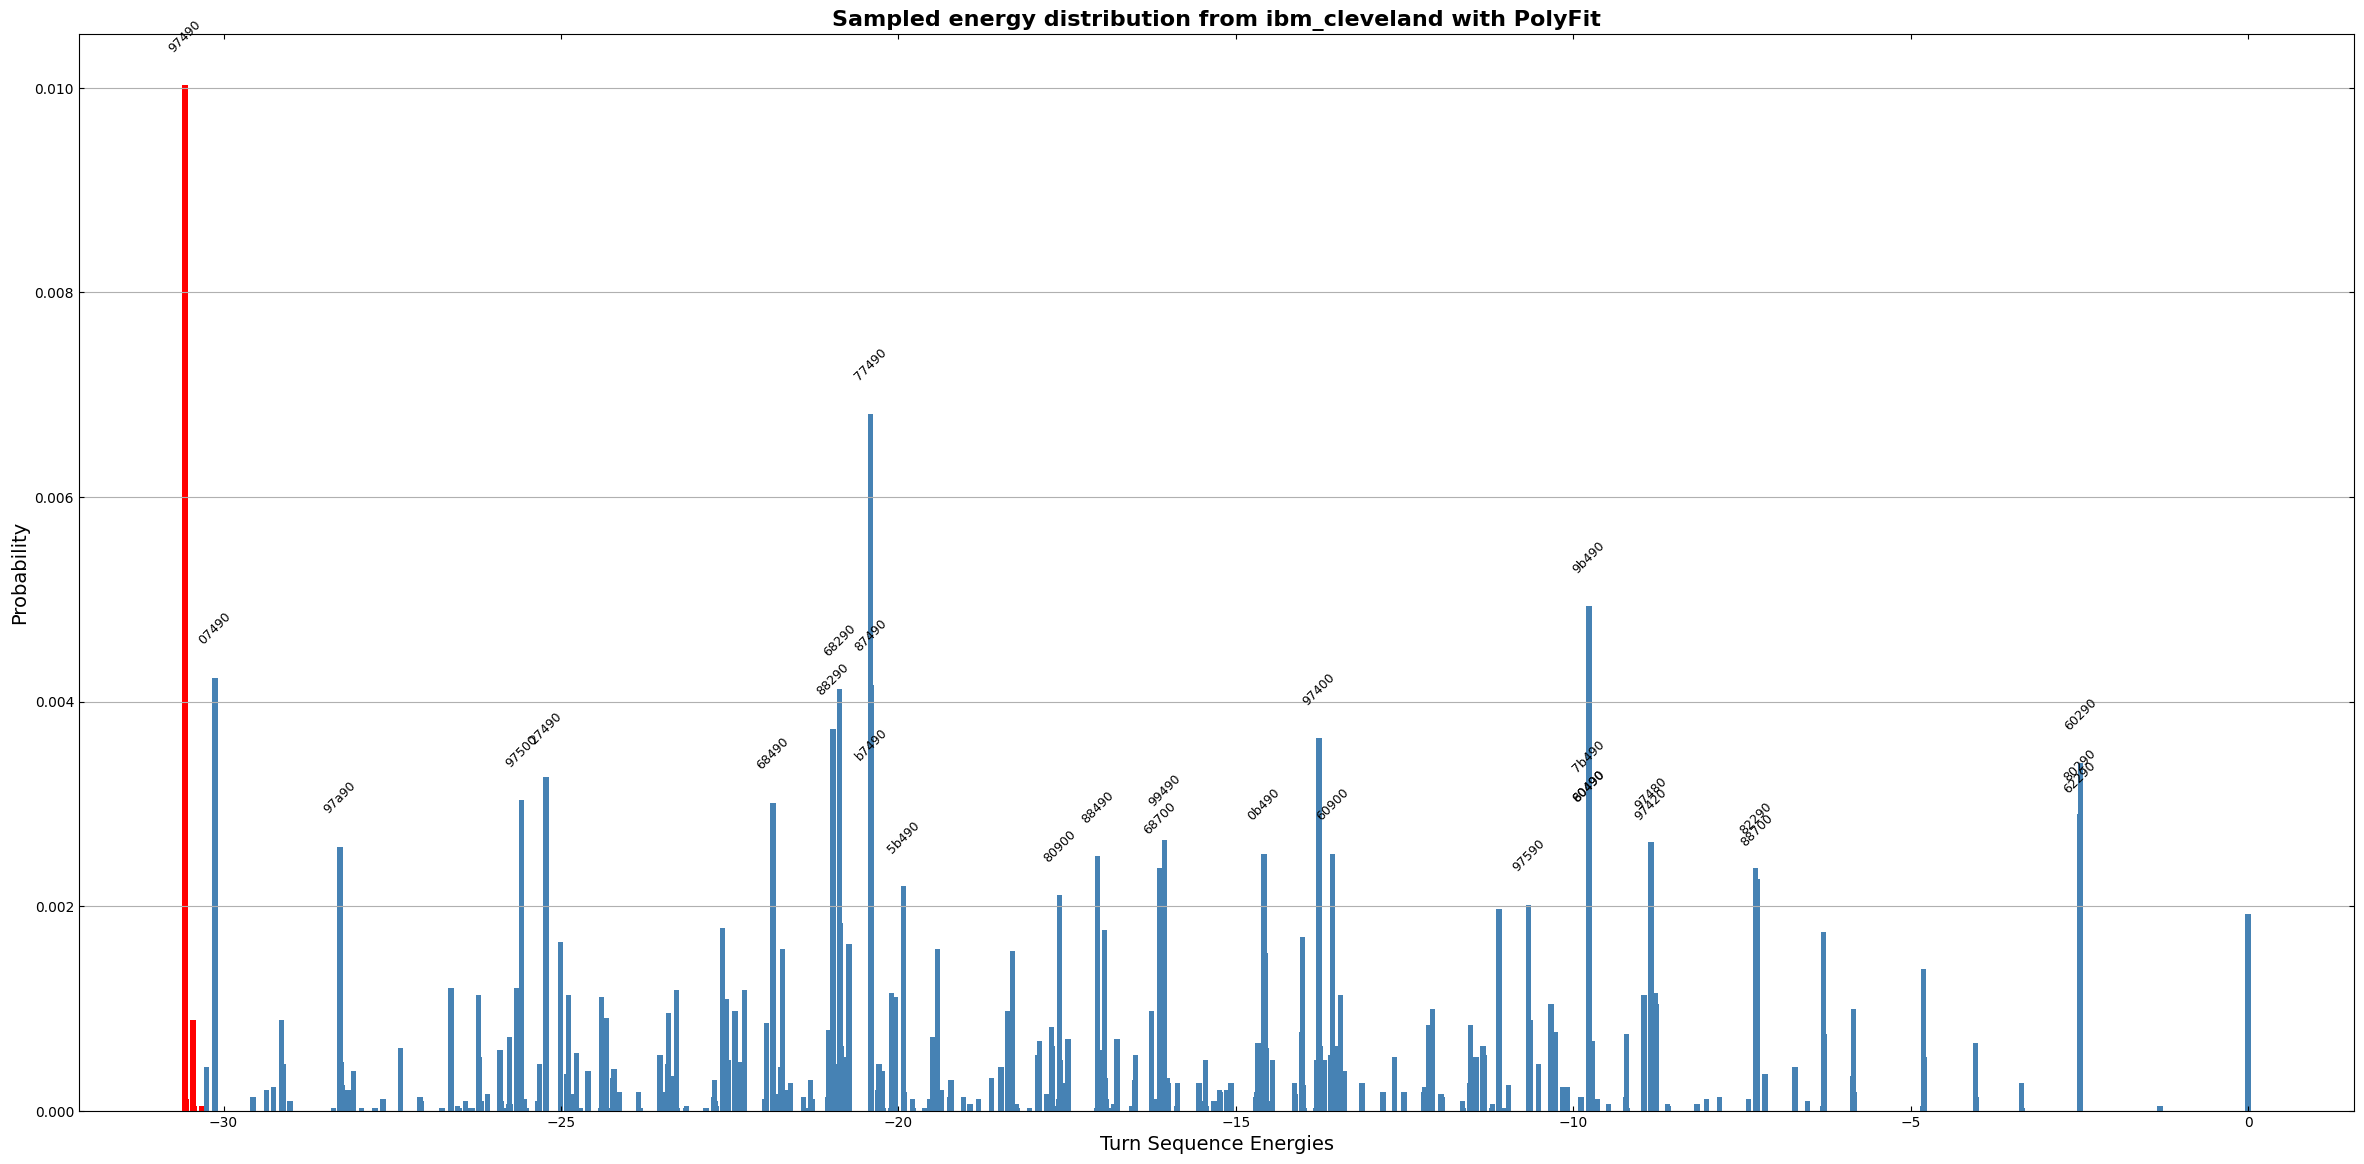

In [49]:
# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490',
                 '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = ibm_cleveland_polyfit
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Configurable label threshold ---
label_threshold = 0.002  # Only label bars with probability above this

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy (ascending) ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=0.08, color=bar_colors, align='center')
ax.set_xlabel("Turn Sequence Energies", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.set_title("Sampled energy distribution from ibm_cleveland with PolyFit", fontsize=16, fontweight='bold')
ax.grid(True, axis='y')

# --- Annotate bars with turn sequences above threshold ---
for x, y, turn in zip(x_vals, y_vals, sorted_turns):
    if y > label_threshold:
        ax.text(x, y + 0.0003, turn, ha='center', va='bottom', fontsize=9, rotation=45)

# --- Aesthetic ticks ---
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout(pad=2.0)
plt.show()


# ibm_kingston plots for polyfit

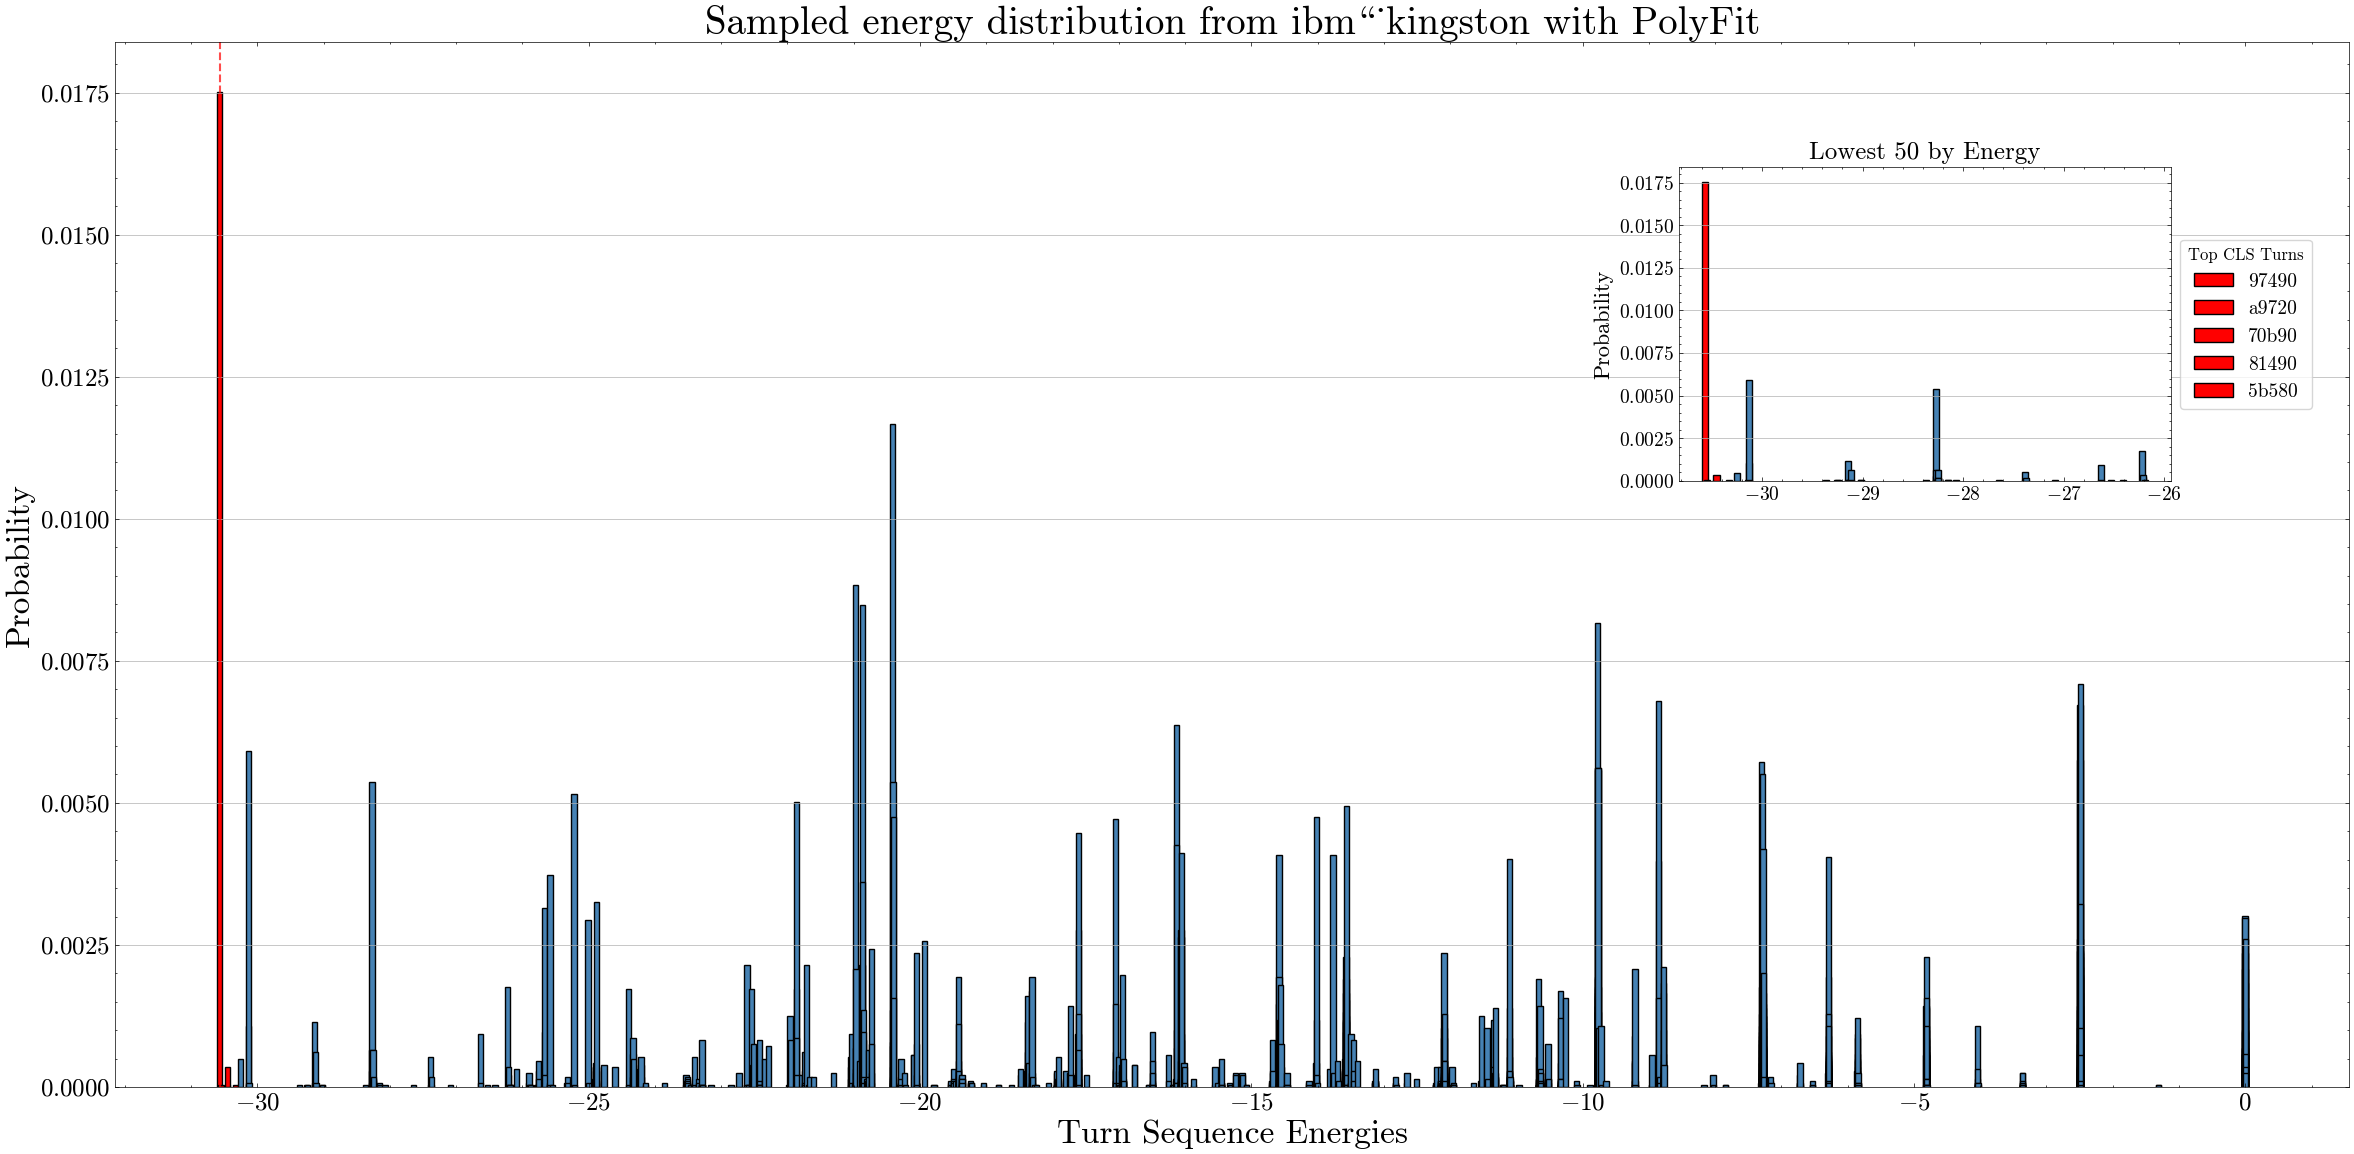

In [51]:
plt.style.use(['science', 'no-latex'])

# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = ibm_kingston_polyfit
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Adjustable bar width ---
bar_width = 0.08

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=bar_width, color=bar_colors, align='center', edgecolor='black')

ax.set_xlabel("Turn Sequence Energies", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
ax.set_title("Sampled energy distribution from ibm\_kingston with PolyFit", fontsize=28, fontweight='bold')
ax.tick_params(axis='x', labelsize=18, which='major', direction='in', top=True)
ax.tick_params(axis='y', labelsize=18, which='major', direction='in', right=True)
ax.grid(True, axis='y')

# --- Highlight lowest energy ---
lowest_energy = min(neg_energies.values())
ax.axvline(x=lowest_energy, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Inset plot (wider + shorter) ---
inset_ax = ax.inset_axes([0.70, 0.58, 0.22, 0.30])
full_sorted_turns = sorted(energies_raw.keys(), key=lambda t: energies_raw[t])
inset_x = [energies_raw[t] for t in full_sorted_turns[:50]]
inset_y = [probs_raw[t] for t in full_sorted_turns[:50]]
inset_colors = ['red' if t in top_cls_turns else 'steelblue' for t in full_sorted_turns[:50]]

bars_inset = inset_ax.bar(inset_x, inset_y, width=0.06, color=inset_colors, edgecolor='black')
inset_ax.set_title("Lowest 50 by Energy", fontsize=18)
inset_ax.set_ylabel("Probability", fontsize=16)
inset_ax.tick_params(axis='x', labelsize=14, which='major', direction='in', top=True)
inset_ax.tick_params(axis='y', labelsize=14, which='major', direction='in', right=True)
inset_ax.grid(True, axis='y')

# --- Legend for inset ---
legend_handles = []
legend_labels = []
for bar, turn in zip(bars_inset, full_sorted_turns[:50]):
    if turn in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn)

if legend_handles:
    inset_ax.legend(
        legend_handles,
        legend_labels,
        title="Top CLS Turns",
        fontsize=14,
        title_fontsize=12,
        loc="center left",
        bbox_to_anchor=(1, 0.5),  # right outside the inset, vertically centered
        borderaxespad=0.5,
        frameon=True
    )

plt.tight_layout(pad=2.0)

# --- Save (commented out) ---
plt.savefig("ibm_kingston_polyfit.pdf", dpi=400, bbox_inches='tight')
plt.show()


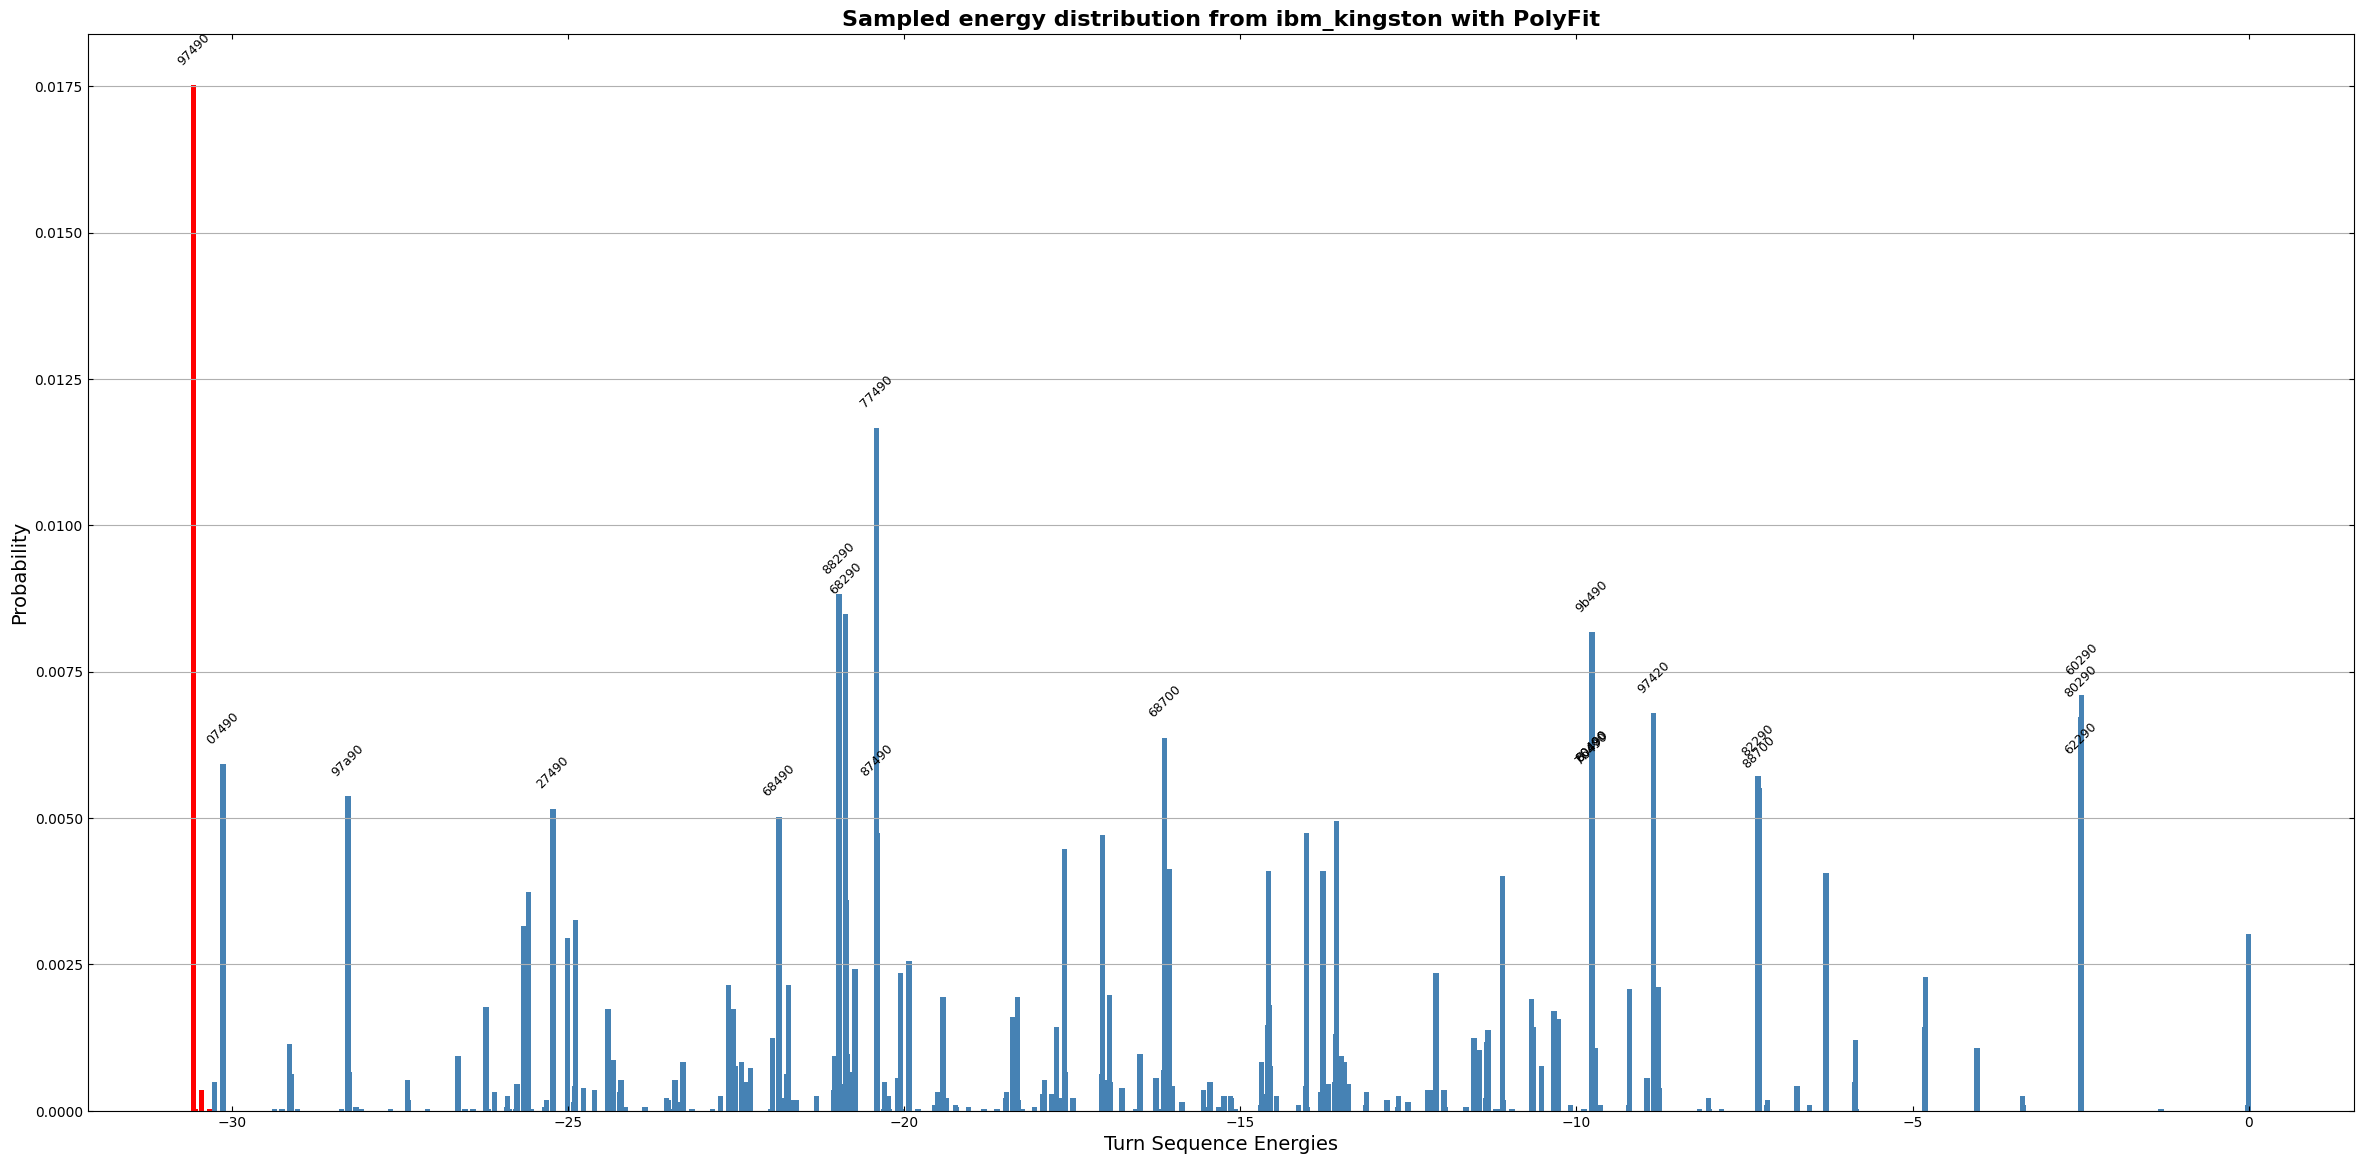

In [60]:
# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490',
                 '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = ibm_kingston_polyfit  
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Configurable label threshold ---
label_threshold = 0.005  # Only label bars with probability above this

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy (ascending) ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=0.08, color=bar_colors, align='center')
ax.set_xlabel("Turn Sequence Energies", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.set_title("Sampled energy distribution from ibm_kingston with PolyFit", fontsize=16, fontweight='bold')
ax.grid(True, axis='y')

# --- Annotate bars with turn sequences above threshold ---
for x, y, turn in zip(x_vals, y_vals, sorted_turns):
    if y > label_threshold:
        ax.text(x, y + 0.0003, turn, ha='center', va='bottom', fontsize=9, rotation=45)

# --- Aesthetic ticks ---
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout(pad=2.0)

# --- Save as high-resolution JPEG ---
plt.savefig("ibm_kingston_polyfit_labeled.jpeg", dpi=400, bbox_inches='tight')
plt.show()


# ibm_cleveland plots for VQEC

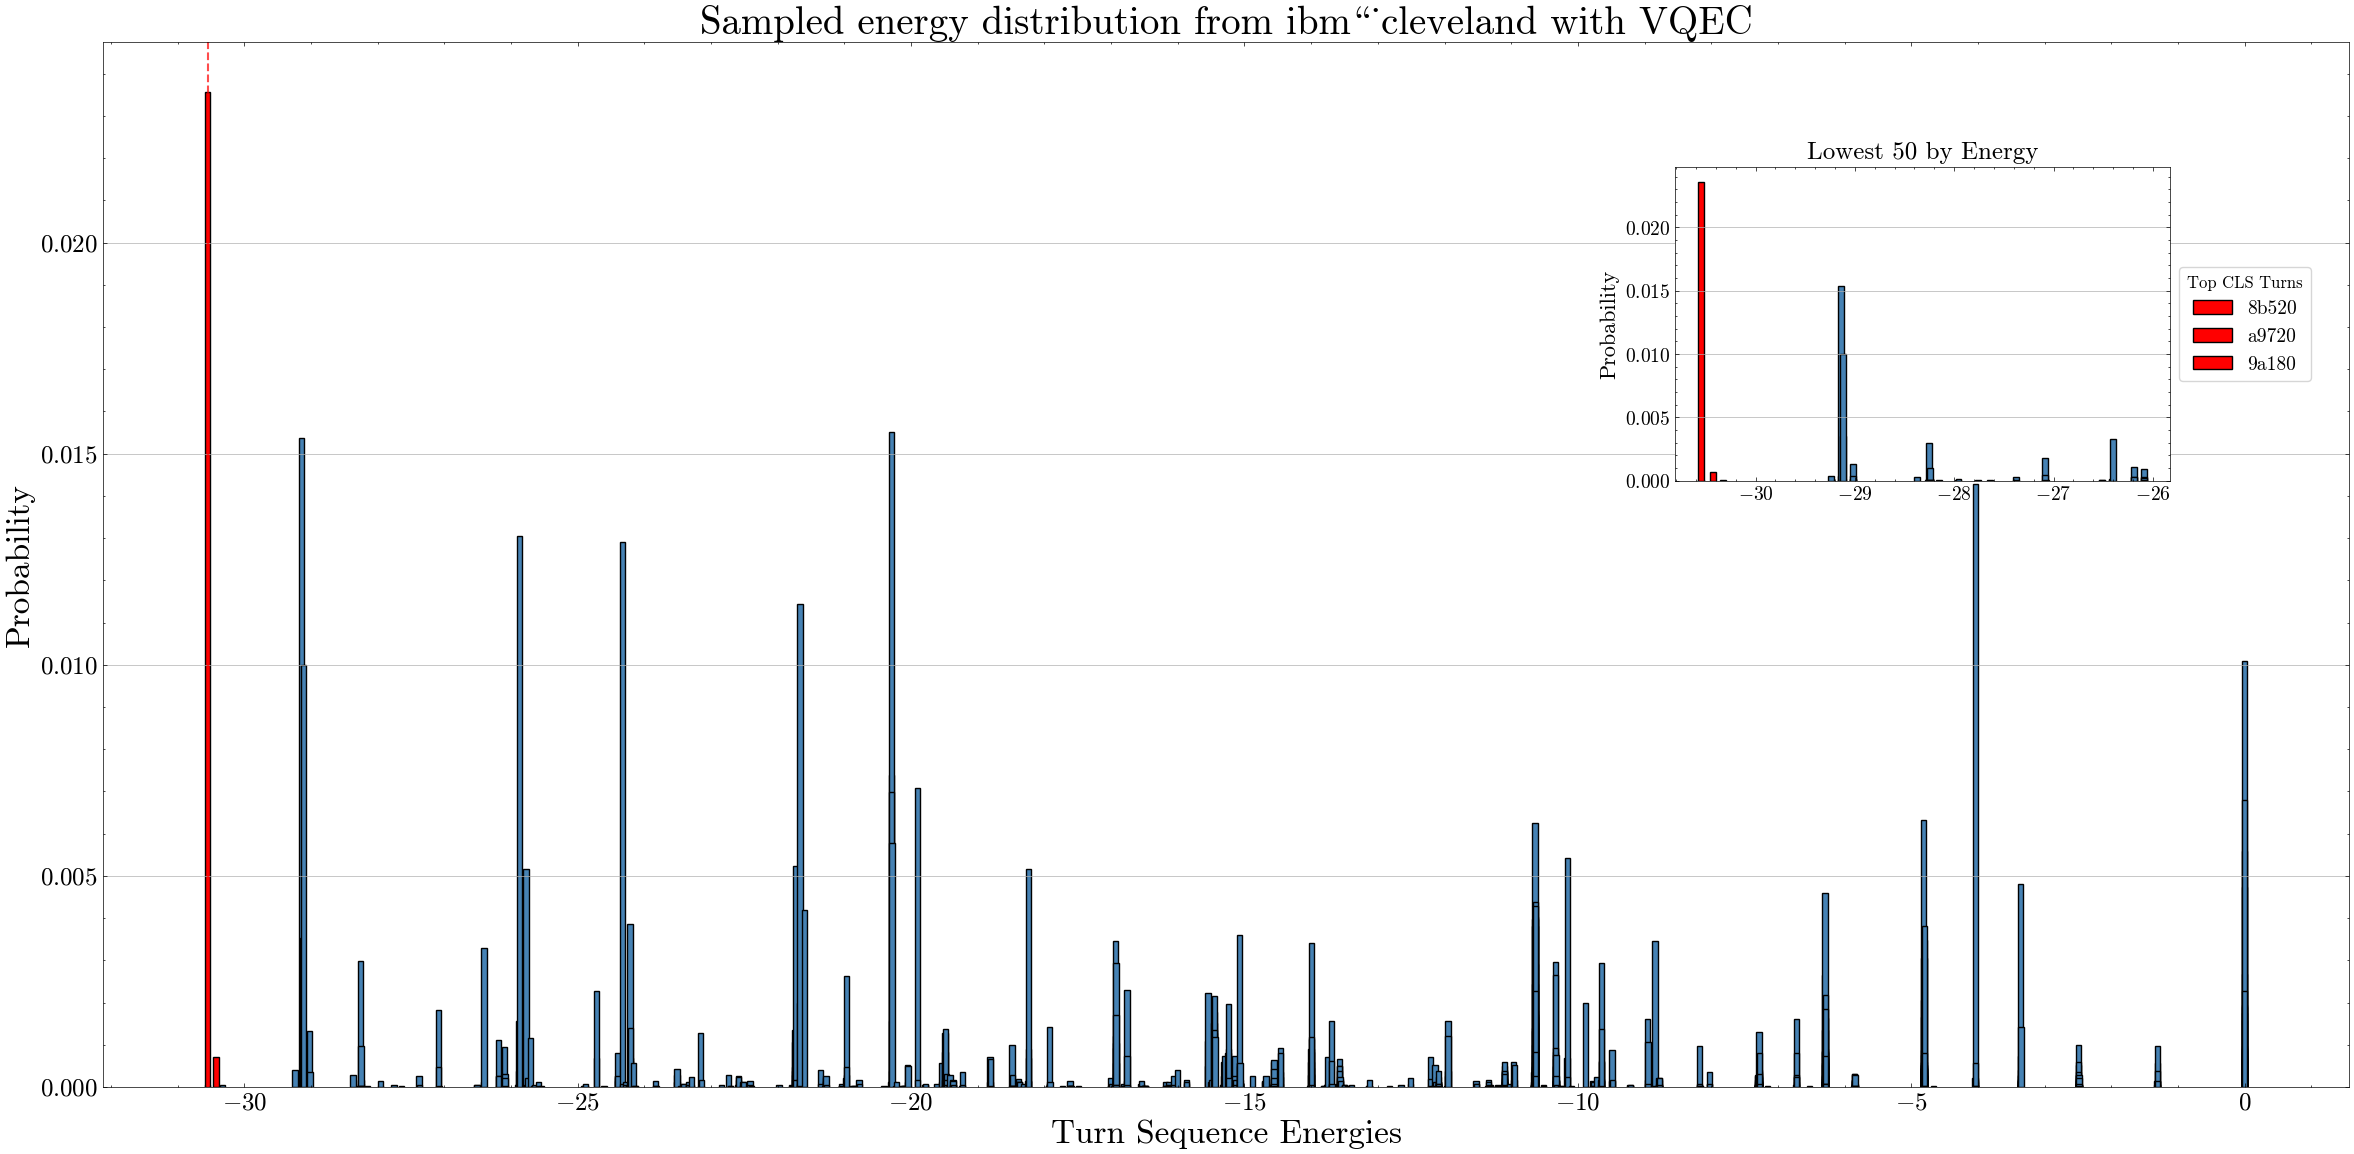

In [52]:
plt.style.use(['science', 'no-latex'])

# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = ibm_cleveland_vqec
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Adjustable bar width ---
bar_width = 0.08

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=bar_width, color=bar_colors, align='center', edgecolor='black')

ax.set_xlabel("Turn Sequence Energies", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
ax.set_title("Sampled energy distribution from ibm\_cleveland with VQEC", fontsize=28, fontweight='bold')
ax.tick_params(axis='x', labelsize=18, which='major', direction='in', top=True)
ax.tick_params(axis='y', labelsize=18, which='major', direction='in', right=True)
ax.grid(True, axis='y')

# --- Highlight lowest energy ---
lowest_energy = min(neg_energies.values())
ax.axvline(x=lowest_energy, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Inset plot (wider + shorter) ---
inset_ax = ax.inset_axes([0.70, 0.58, 0.22, 0.30])
full_sorted_turns = sorted(energies_raw.keys(), key=lambda t: energies_raw[t])
inset_x = [energies_raw[t] for t in full_sorted_turns[:50]]
inset_y = [probs_raw[t] for t in full_sorted_turns[:50]]
inset_colors = ['red' if t in top_cls_turns else 'steelblue' for t in full_sorted_turns[:50]]

bars_inset = inset_ax.bar(inset_x, inset_y, width=0.06, color=inset_colors, edgecolor='black')
inset_ax.set_title("Lowest 50 by Energy", fontsize=18)
inset_ax.set_ylabel("Probability", fontsize=16)
inset_ax.tick_params(axis='x', labelsize=14, which='major', direction='in', top=True)
inset_ax.tick_params(axis='y', labelsize=14, which='major', direction='in', right=True)
inset_ax.grid(True, axis='y')

# --- Legend for inset ---
legend_handles = []
legend_labels = []
for bar, turn in zip(bars_inset, full_sorted_turns[:50]):
    if turn in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn)

if legend_handles:
    inset_ax.legend(
        legend_handles,
        legend_labels,
        title="Top CLS Turns",
        fontsize=14,
        title_fontsize=12,
        loc="center left",
        bbox_to_anchor=(1, 0.5),  # right outside the inset, vertically centered
        borderaxespad=0.5,
        frameon=True
    )

plt.tight_layout(pad=2.0)

# --- Save (commented out) ---
plt.savefig("ibm_cleveland_vqec.pdf", dpi=400, bbox_inches='tight')
plt.show()


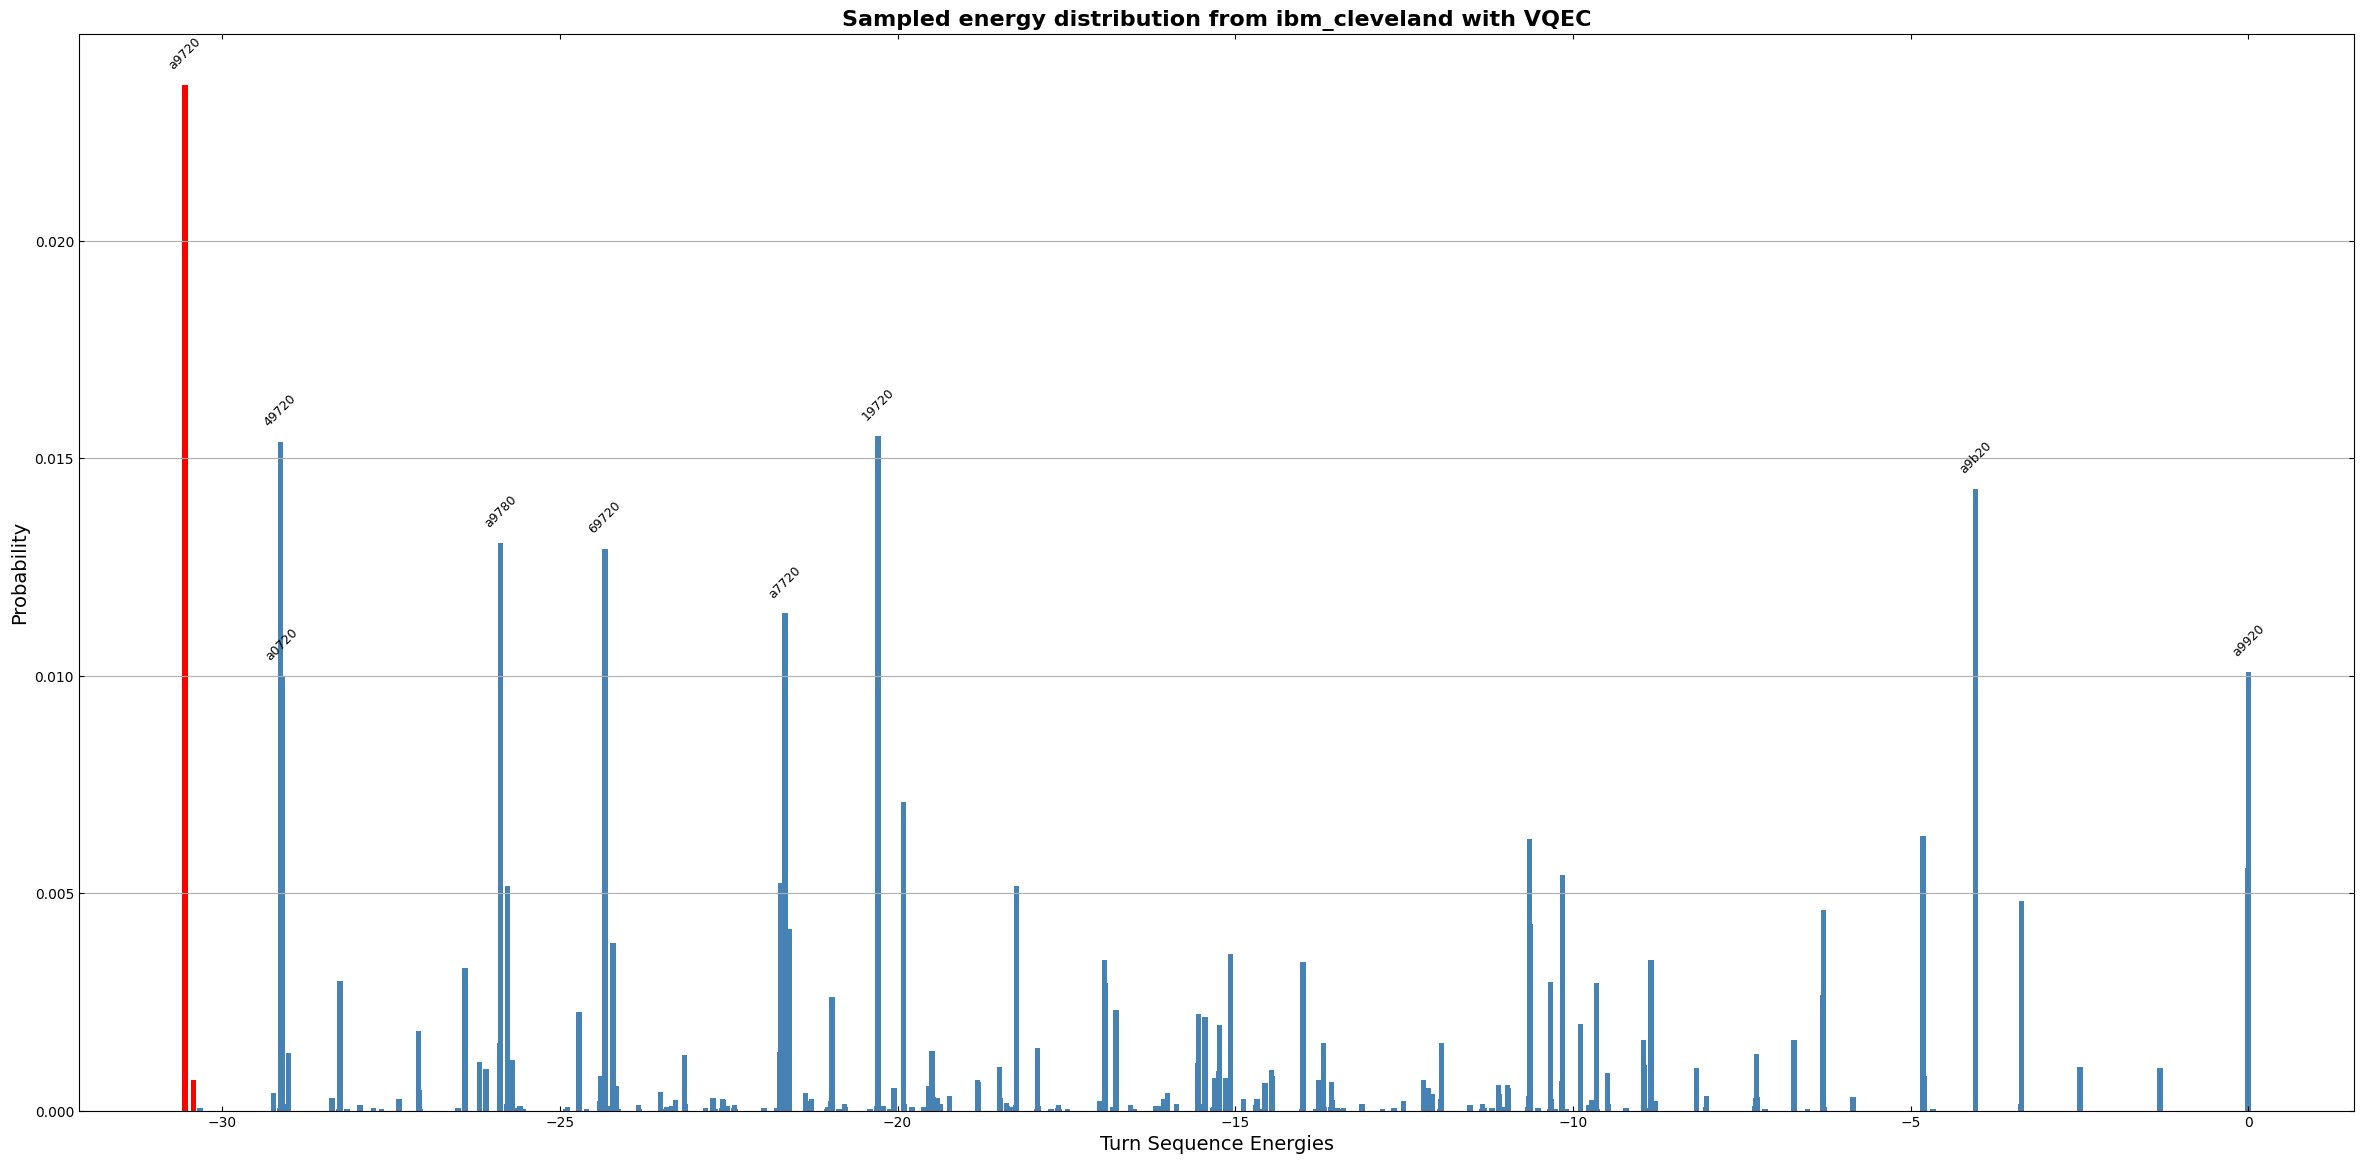

In [62]:
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490',
                 '31a20', '31820', '2b580', '9a180', '5b580'}
data = ibm_cleveland_vqec  

energies_raw = data["energies"]
probs_raw = data["probs"]
label_threshold = 0.01  # adjustable

neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=0.08, color=bar_colors, align='center')
ax.set_xlabel("Turn Sequence Energies", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.set_title("Sampled energy distribution from ibm_cleveland with VQEC", fontsize=16, fontweight='bold')
ax.grid(True, axis='y')

for x, y, turn in zip(x_vals, y_vals, sorted_turns):
    if y > label_threshold:
        ax.text(x, y + 0.0003, turn, ha='center', va='bottom', fontsize=9, rotation=45)

ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("ibm_cleveland_vqec_labeled.jpeg", dpi=400, bbox_inches='tight')
plt.show()


# ibm_kingston plots for VQEC

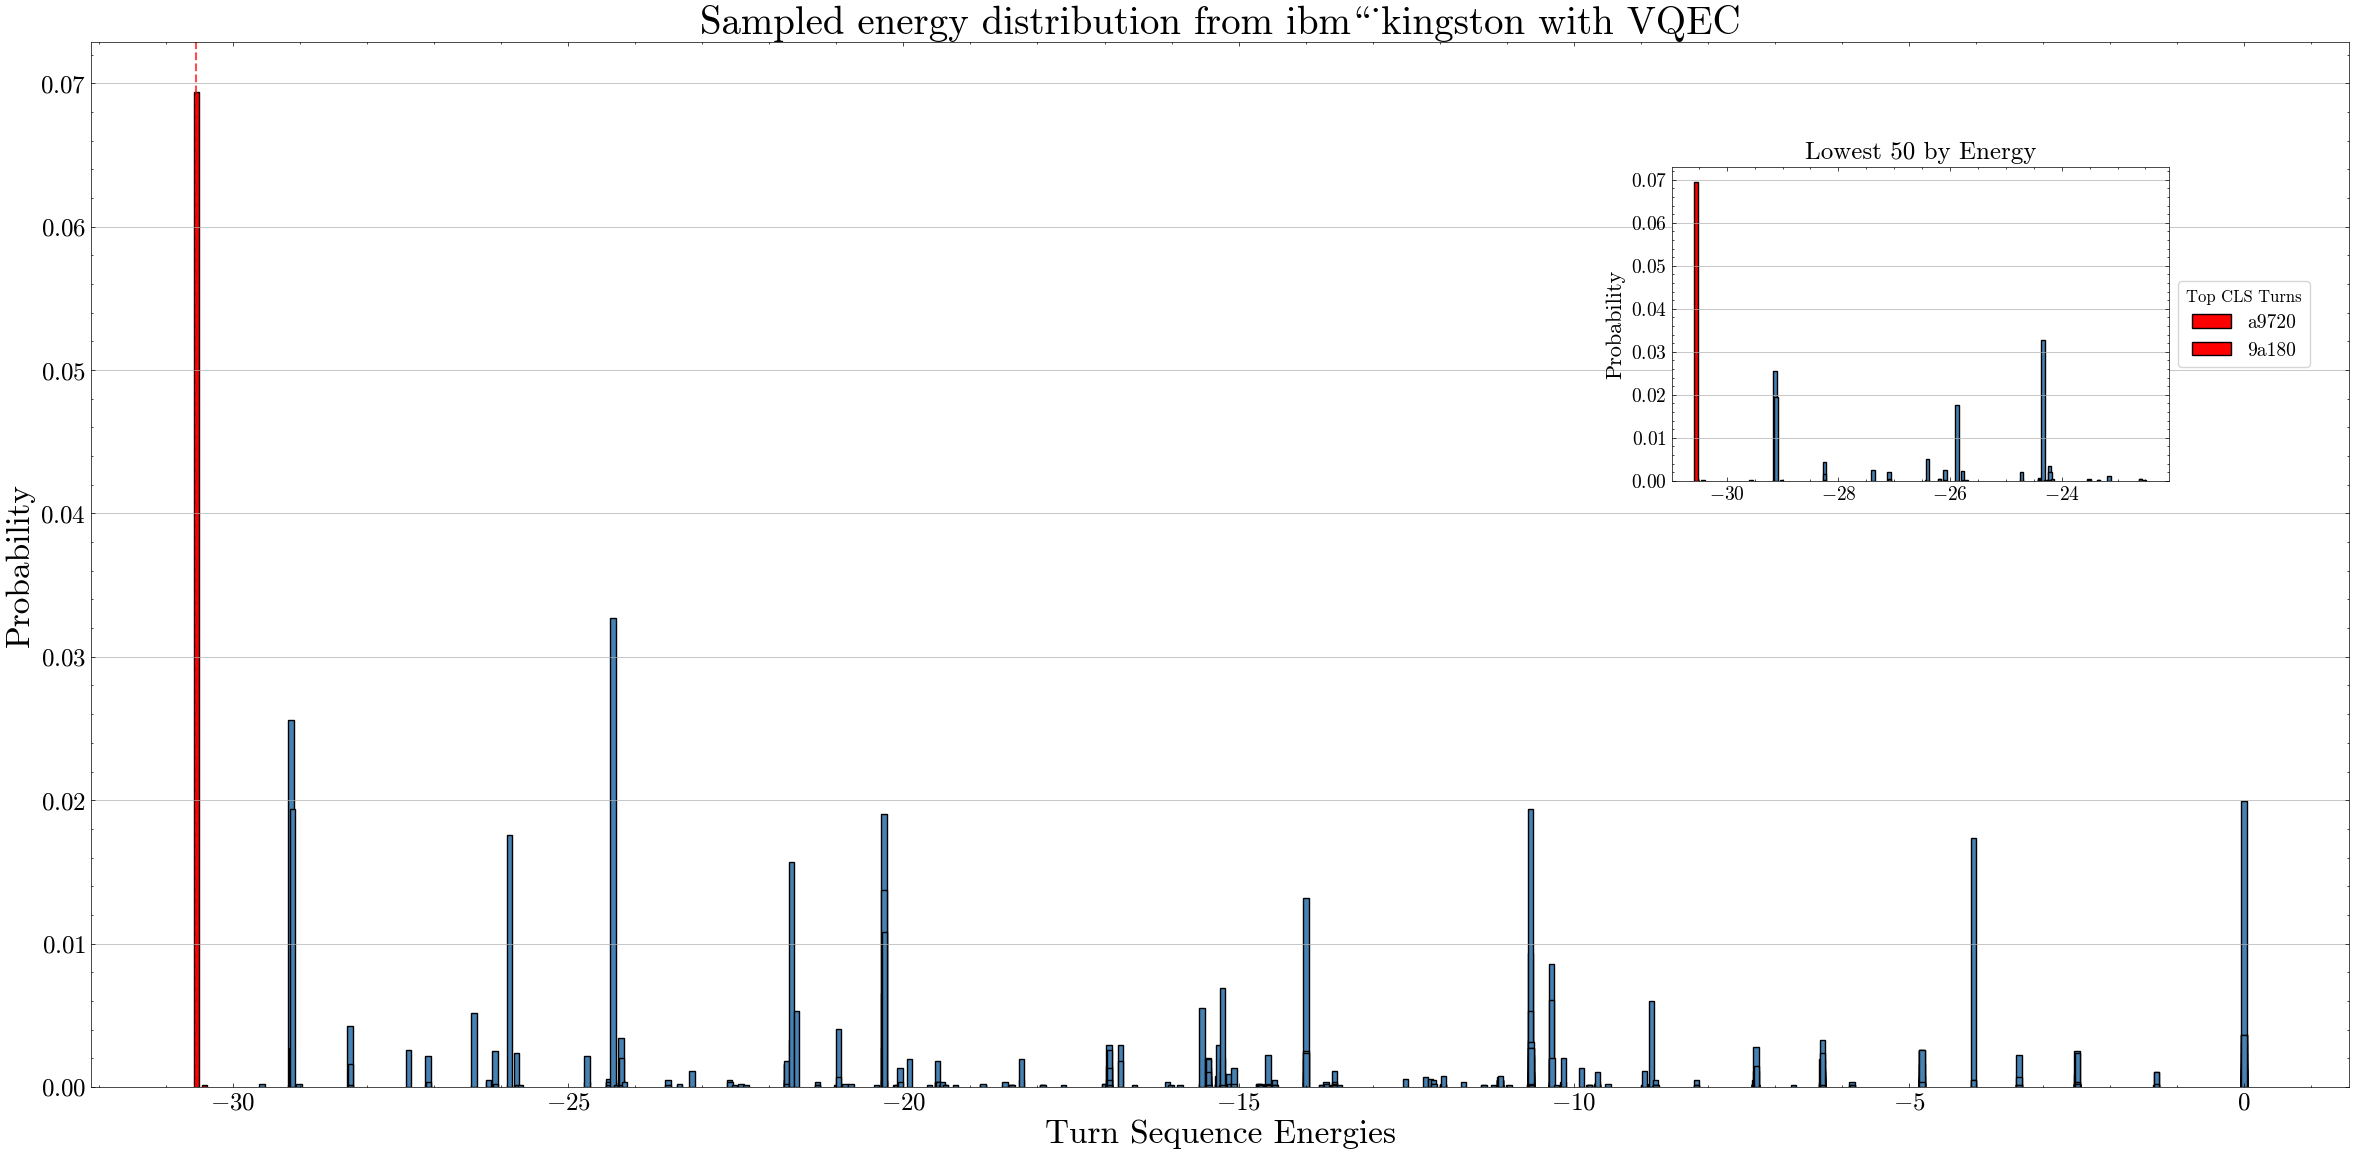

In [53]:
plt.style.use(['science', 'no-latex'])

# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = ibm_kingston_vqec
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Adjustable bar width ---
bar_width = 0.08

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=bar_width, color=bar_colors, align='center', edgecolor='black')

ax.set_xlabel("Turn Sequence Energies", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
ax.set_title("Sampled energy distribution from ibm\_kingston with VQEC", fontsize=28, fontweight='bold')
ax.tick_params(axis='x', labelsize=18, which='major', direction='in', top=True)
ax.tick_params(axis='y', labelsize=18, which='major', direction='in', right=True)
ax.grid(True, axis='y')

# --- Highlight lowest energy ---
lowest_energy = min(neg_energies.values())
ax.axvline(x=lowest_energy, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Inset plot (wider + shorter) ---
inset_ax = ax.inset_axes([0.70, 0.58, 0.22, 0.30])
full_sorted_turns = sorted(energies_raw.keys(), key=lambda t: energies_raw[t])
inset_x = [energies_raw[t] for t in full_sorted_turns[:50]]
inset_y = [probs_raw[t] for t in full_sorted_turns[:50]]
inset_colors = ['red' if t in top_cls_turns else 'steelblue' for t in full_sorted_turns[:50]]

bars_inset = inset_ax.bar(inset_x, inset_y, width=0.06, color=inset_colors, edgecolor='black')
inset_ax.set_title("Lowest 50 by Energy", fontsize=18)
inset_ax.set_ylabel("Probability", fontsize=16)
inset_ax.tick_params(axis='x', labelsize=14, which='major', direction='in', top=True)
inset_ax.tick_params(axis='y', labelsize=14, which='major', direction='in', right=True)
inset_ax.grid(True, axis='y')

# --- Legend for inset ---
legend_handles = []
legend_labels = []
for bar, turn in zip(bars_inset, full_sorted_turns[:50]):
    if turn in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn)

if legend_handles:
    inset_ax.legend(
        legend_handles,
        legend_labels,
        title="Top CLS Turns",
        fontsize=14,
        title_fontsize=12,
        loc="center left",
        bbox_to_anchor=(1, 0.5),  # right outside the inset, vertically centered
        borderaxespad=0.5,
        frameon=True
    )

plt.tight_layout(pad=2.0)

# --- Save (commented out) ---
plt.savefig("ibm_kingston_vqec.pdf", dpi=400, bbox_inches='tight')
plt.show()


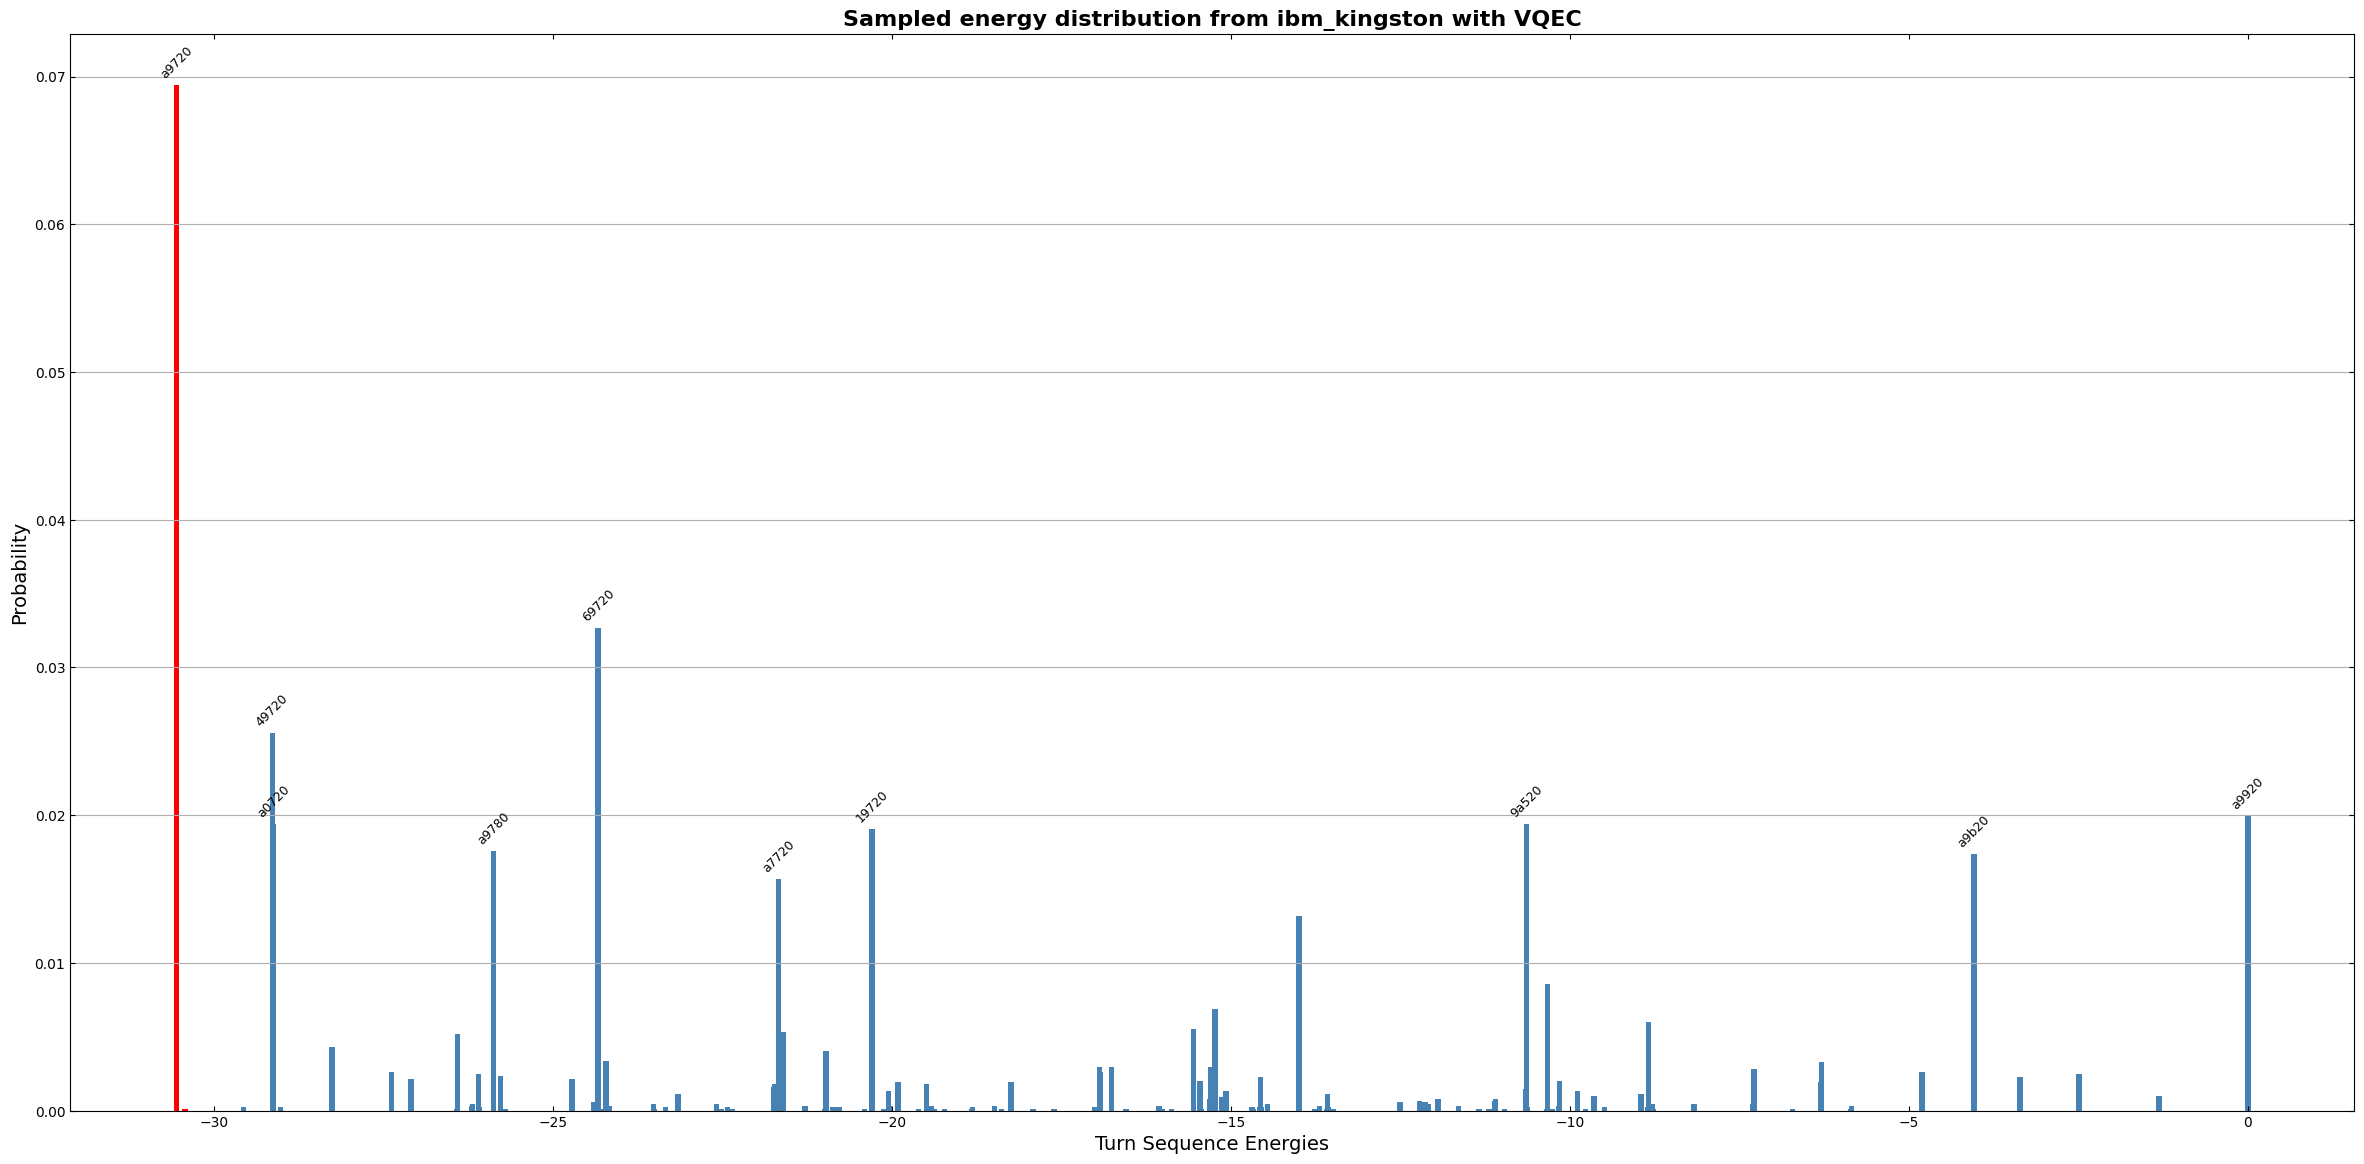

In [64]:
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490',
                 '31a20', '31820', '2b580', '9a180', '5b580'}
data = ibm_kingston_vqec  

energies_raw = data["energies"]
probs_raw = data["probs"]
label_threshold = 0.015  # adjustable threshold for label display

neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=0.08, color=bar_colors, align='center')
ax.set_xlabel("Turn Sequence Energies", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.set_title("Sampled energy distribution from ibm_kingston with VQEC", fontsize=16, fontweight='bold')
ax.grid(True, axis='y')

for x, y, turn in zip(x_vals, y_vals, sorted_turns):
    if y > label_threshold:
        ax.text(x, y + 0.0003, turn, ha='center', va='bottom', fontsize=9, rotation=45)

ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("ibm_kingston_vqec_labeled.jpeg", dpi=400, bbox_inches='tight')
plt.show()


# plots for mps runs

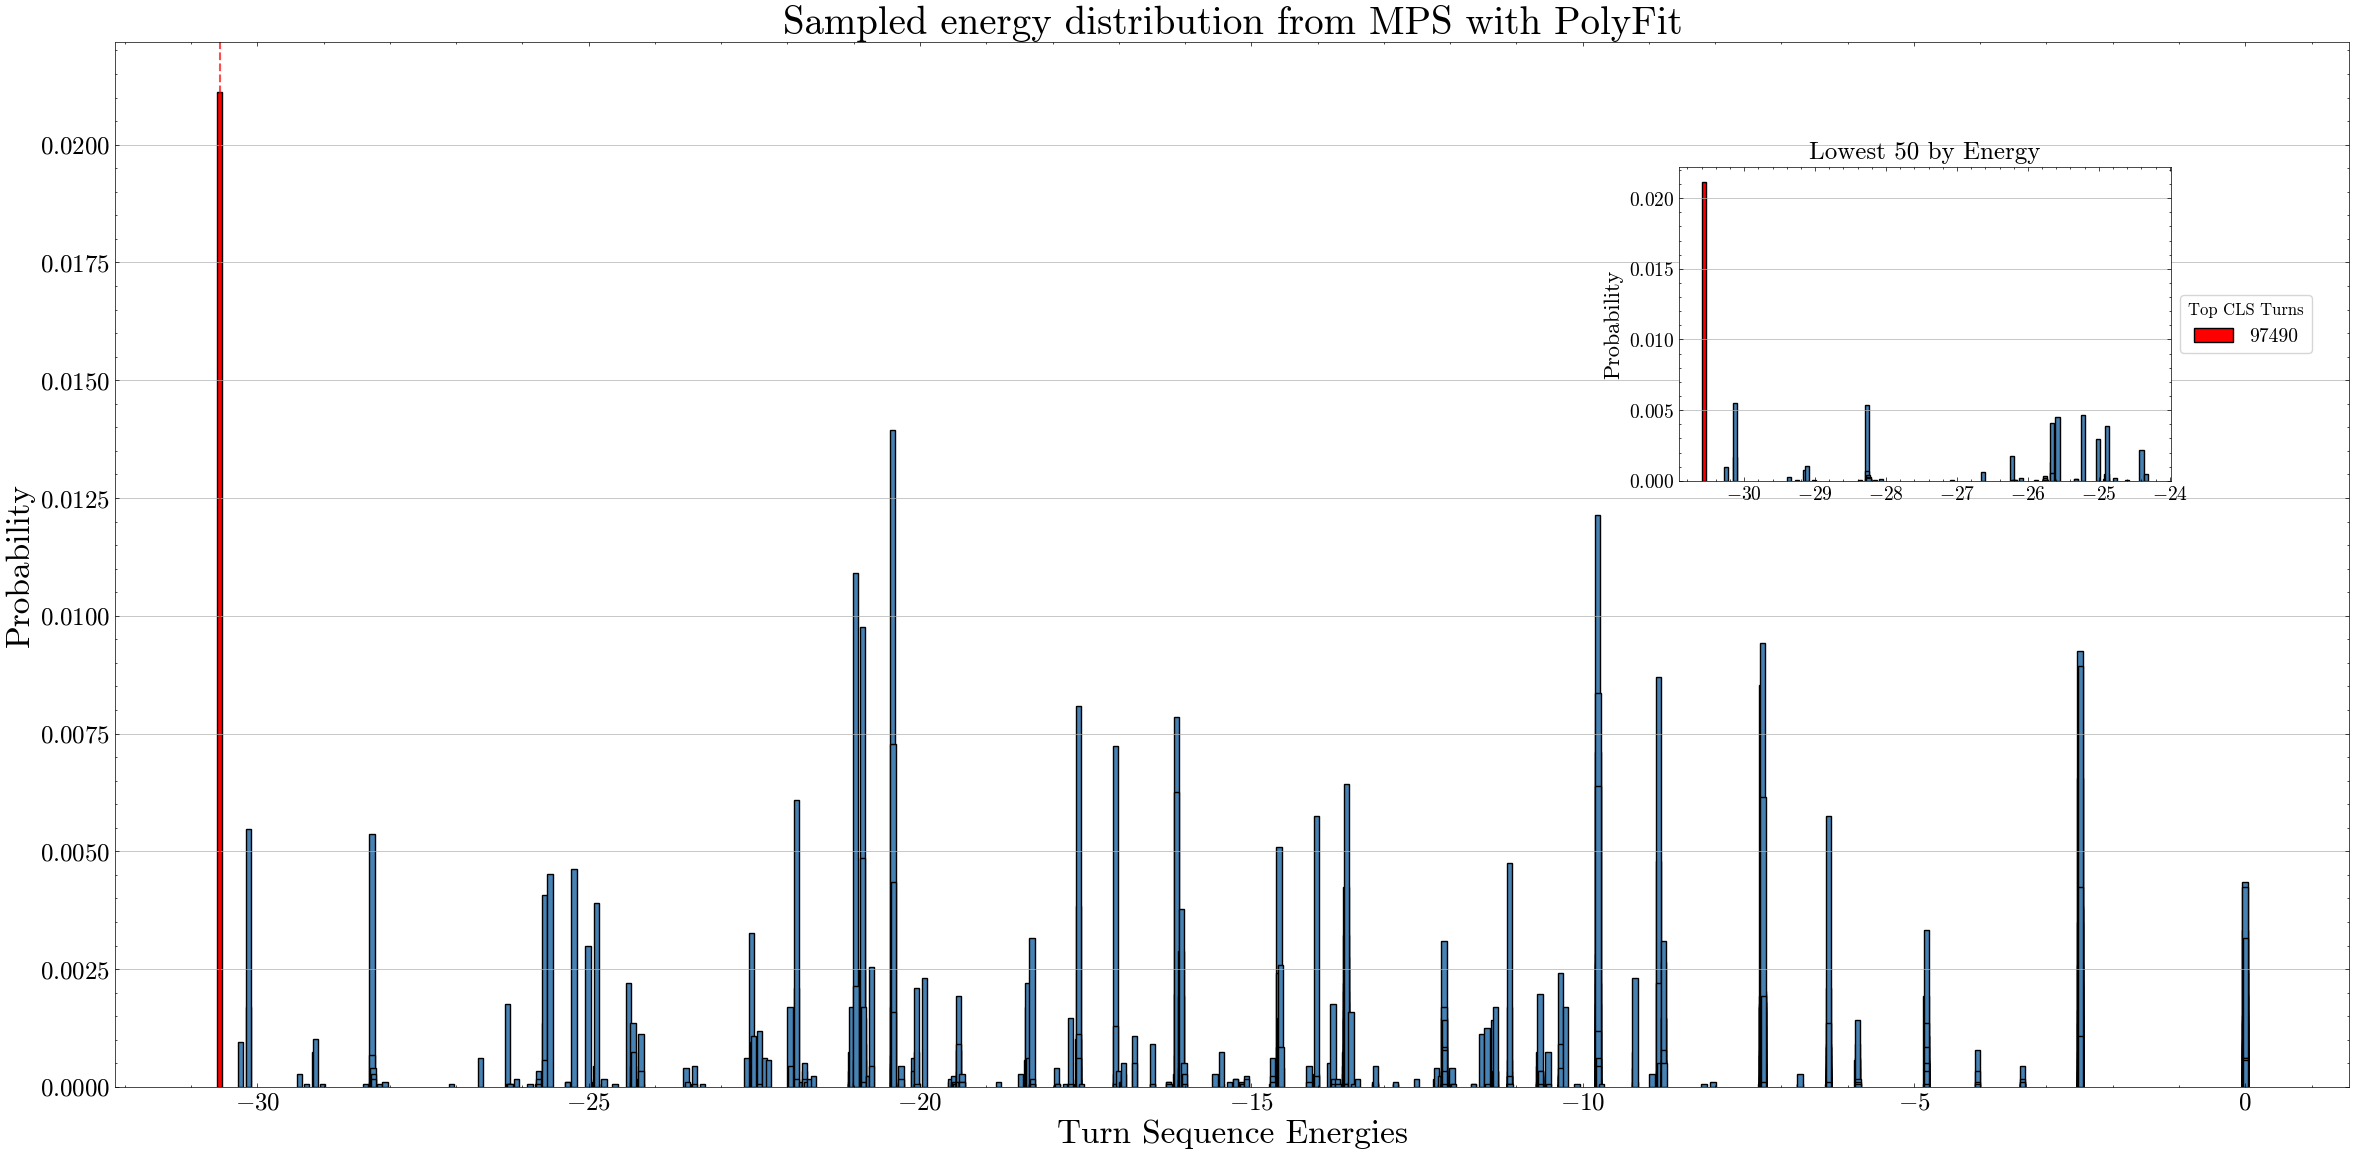

In [56]:
plt.style.use(['science', 'no-latex'])

# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = mps_polyfit
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Adjustable bar width ---
bar_width = 0.08

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=bar_width, color=bar_colors, align='center', edgecolor='black')

ax.set_xlabel("Turn Sequence Energies", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
ax.set_title("Sampled energy distribution from MPS with PolyFit", fontsize=28, fontweight='bold')
ax.tick_params(axis='x', labelsize=18, which='major', direction='in', top=True)
ax.tick_params(axis='y', labelsize=18, which='major', direction='in', right=True)
ax.grid(True, axis='y')

# --- Highlight lowest energy ---
lowest_energy = min(neg_energies.values())
ax.axvline(x=lowest_energy, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Inset plot (wider + shorter) ---
inset_ax = ax.inset_axes([0.70, 0.58, 0.22, 0.30])
full_sorted_turns = sorted(energies_raw.keys(), key=lambda t: energies_raw[t])
inset_x = [energies_raw[t] for t in full_sorted_turns[:50]]
inset_y = [probs_raw[t] for t in full_sorted_turns[:50]]
inset_colors = ['red' if t in top_cls_turns else 'steelblue' for t in full_sorted_turns[:50]]

bars_inset = inset_ax.bar(inset_x, inset_y, width=0.06, color=inset_colors, edgecolor='black')
inset_ax.set_title("Lowest 50 by Energy", fontsize=18)
inset_ax.set_ylabel("Probability", fontsize=16)
inset_ax.tick_params(axis='x', labelsize=14, which='major', direction='in', top=True)
inset_ax.tick_params(axis='y', labelsize=14, which='major', direction='in', right=True)
inset_ax.grid(True, axis='y')

# --- Legend for inset ---
legend_handles = []
legend_labels = []
for bar, turn in zip(bars_inset, full_sorted_turns[:50]):
    if turn in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn)

if legend_handles:
    inset_ax.legend(
        legend_handles,
        legend_labels,
        title="Top CLS Turns",
        fontsize=14,
        title_fontsize=12,
        loc="center left",
        bbox_to_anchor=(1, 0.5),  # right outside the inset, vertically centered
        borderaxespad=0.5,
        frameon=True
    )

plt.tight_layout(pad=2.0)

# --- Save (commented out) ---
plt.savefig("mpsrun0_polyfit.pdf", dpi=400, bbox_inches='tight')
plt.show()


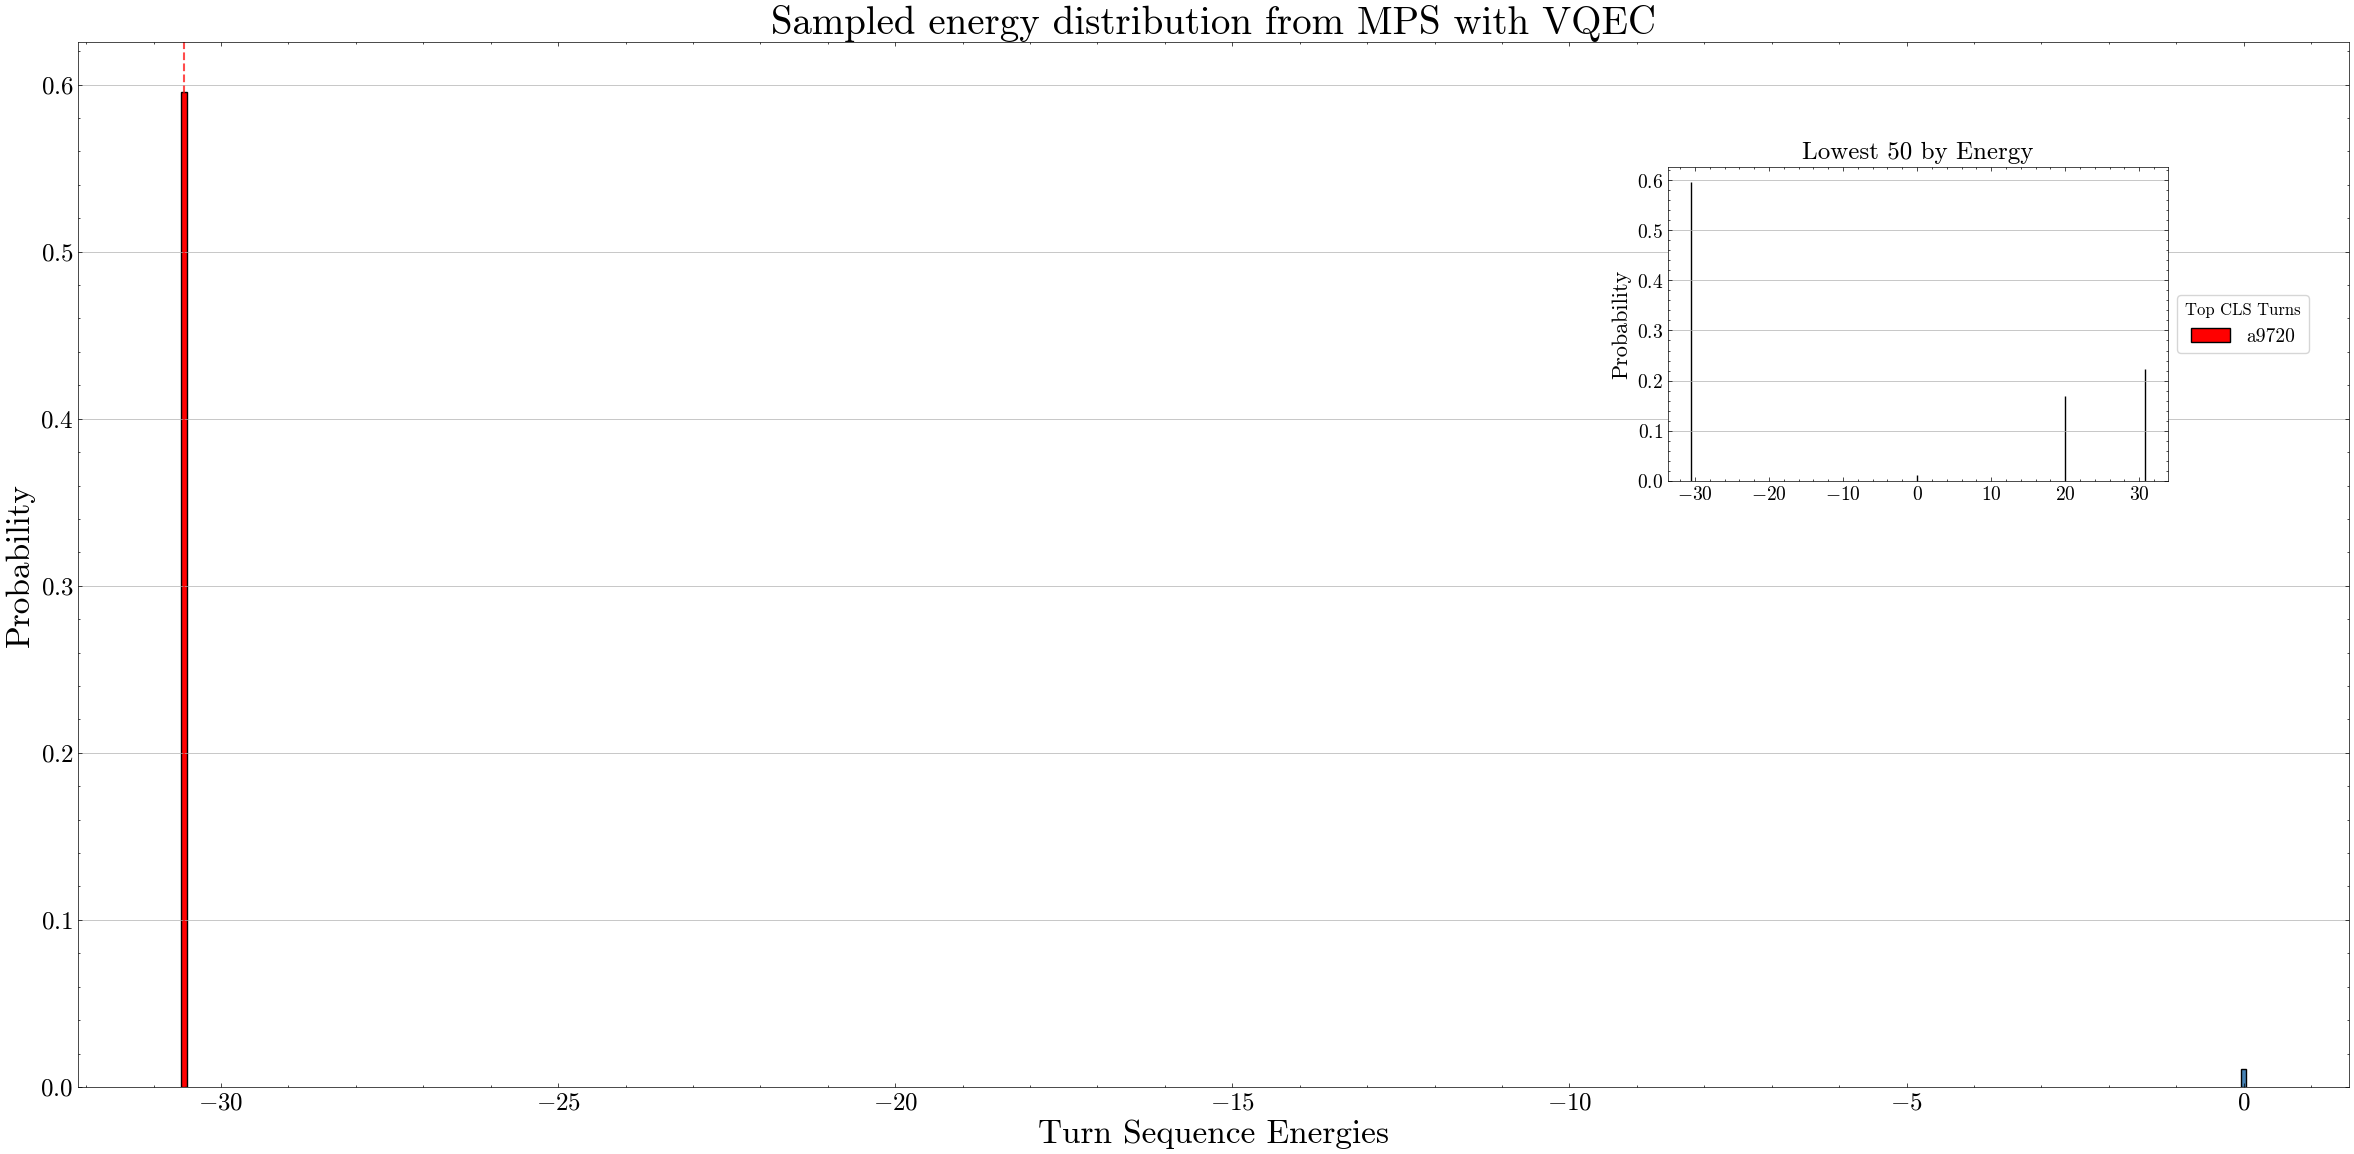

In [57]:
plt.style.use(['science', 'no-latex'])

# --- CLS turn sequences ---
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# --- Select dataset ---
data = mps_vqec
energies_raw = data["energies"]
probs_raw = data["probs"]

# --- Filter only negative-energy entries ---
neg_keys = [k for k in energies_raw if energies_raw[k] < 0]
neg_energies = {k: energies_raw[k] for k in neg_keys}
neg_probs = {k: probs_raw[k] for k in neg_keys}

# --- Sort by energy ---
sorted_turns = sorted(neg_energies.keys(), key=lambda t: neg_energies[t])
x_vals = [neg_energies[t] for t in sorted_turns]
y_vals = [neg_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Adjustable bar width ---
bar_width = 0.08

# --- Plot ---
fig, ax = plt.subplots(figsize=(24, 12))
bars = ax.bar(x_vals, y_vals, width=bar_width, color=bar_colors, align='center', edgecolor='black')

ax.set_xlabel("Turn Sequence Energies", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
ax.set_title("Sampled energy distribution from MPS with VQEC", fontsize=28, fontweight='bold')
ax.tick_params(axis='x', labelsize=18, which='major', direction='in', top=True)
ax.tick_params(axis='y', labelsize=18, which='major', direction='in', right=True)
ax.grid(True, axis='y')

# --- Highlight lowest energy ---
lowest_energy = min(neg_energies.values())
ax.axvline(x=lowest_energy, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Inset plot (wider + shorter) ---
inset_ax = ax.inset_axes([0.70, 0.58, 0.22, 0.30])
full_sorted_turns = sorted(energies_raw.keys(), key=lambda t: energies_raw[t])
inset_x = [energies_raw[t] for t in full_sorted_turns[:50]]
inset_y = [probs_raw[t] for t in full_sorted_turns[:50]]
inset_colors = ['red' if t in top_cls_turns else 'steelblue' for t in full_sorted_turns[:50]]

bars_inset = inset_ax.bar(inset_x, inset_y, width=0.025, color=inset_colors, edgecolor='black')
inset_ax.set_title("Lowest 50 by Energy", fontsize=18)
inset_ax.set_ylabel("Probability", fontsize=16)
inset_ax.tick_params(axis='x', labelsize=14, which='major', direction='in', top=True)
inset_ax.tick_params(axis='y', labelsize=14, which='major', direction='in', right=True)
inset_ax.grid(True, axis='y')

# --- Legend for inset ---
legend_handles = []
legend_labels = []
for bar, turn in zip(bars_inset, full_sorted_turns[:50]):
    if turn in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn)

if legend_handles:
    inset_ax.legend(
        legend_handles,
        legend_labels,
        title="Top CLS Turns",
        fontsize=14,
        title_fontsize=12,
        loc="center left",
        bbox_to_anchor=(1, 0.5),  # right outside the inset, vertically centered
        borderaxespad=0.5,
        frameon=True
    )

plt.tight_layout(pad=2.0)

# --- Save (commented out) ---
plt.savefig("mps_vqec.pdf", dpi=400, bbox_inches='tight')
plt.show()


# plots for cumulative probs

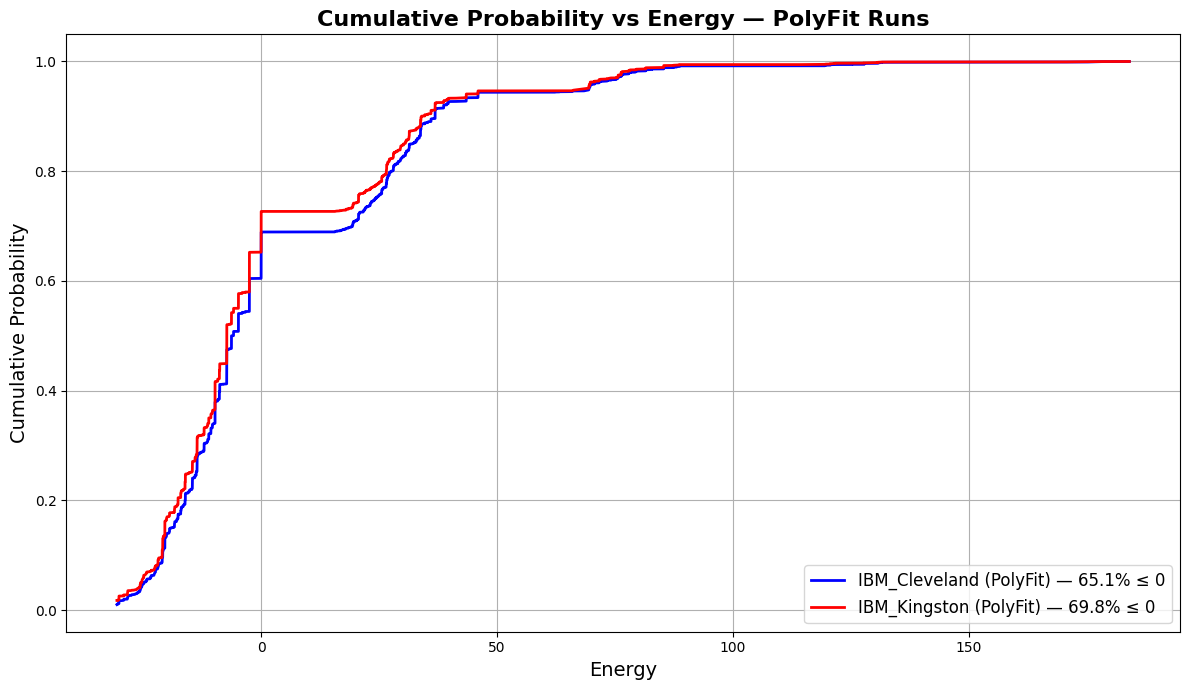

In [71]:
import numpy as np

plt.figure(figsize=(12, 7))

color_map = {
    "IBM_Cleveland (PolyFit)": "blue",
    "IBM_Kingston (PolyFit)": "red"
}

# --- Register the datasets under proper labels ---
all_data_polyfit = {
    "IBM_Cleveland (PolyFit)": ibm_cleveland_polyfit,
    "IBM_Kingston (PolyFit)": ibm_kingston_polyfit
}

for label in ["IBM_Cleveland (PolyFit)", "IBM_Kingston (PolyFit)"]:
    data = all_data_polyfit[label]
    energies = data["energies"]
    probs = data["probs"]

    sorted_turns = sorted(probs.keys(), key=lambda t: energies[t])
    energy_vals = [energies[t] for t in sorted_turns]
    prob_vals = [probs[t] for t in sorted_turns]
    cum_probs = np.cumsum(prob_vals)

    # Compute % mass below E = 0
    cum_below_zero = sum(p for e, p in zip(energy_vals, prob_vals) if e < 0)
    label_augmented = f"{label} — {cum_below_zero:.1%} ≤ 0"

    # Plot cumulative curve with updated label
    plt.plot(energy_vals, cum_probs, label=label_augmented, color=color_map[label], lw=2)

plt.xlabel("Energy", fontsize=14)
plt.ylabel("Cumulative Probability", fontsize=14)
plt.title("Cumulative Probability vs Energy — PolyFit Runs", fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc="lower right")
plt.grid(True)
plt.tight_layout()

# Optional: Save to file
plt.savefig("polyfit_cumulative_probability.jpeg", dpi=400)

plt.show()


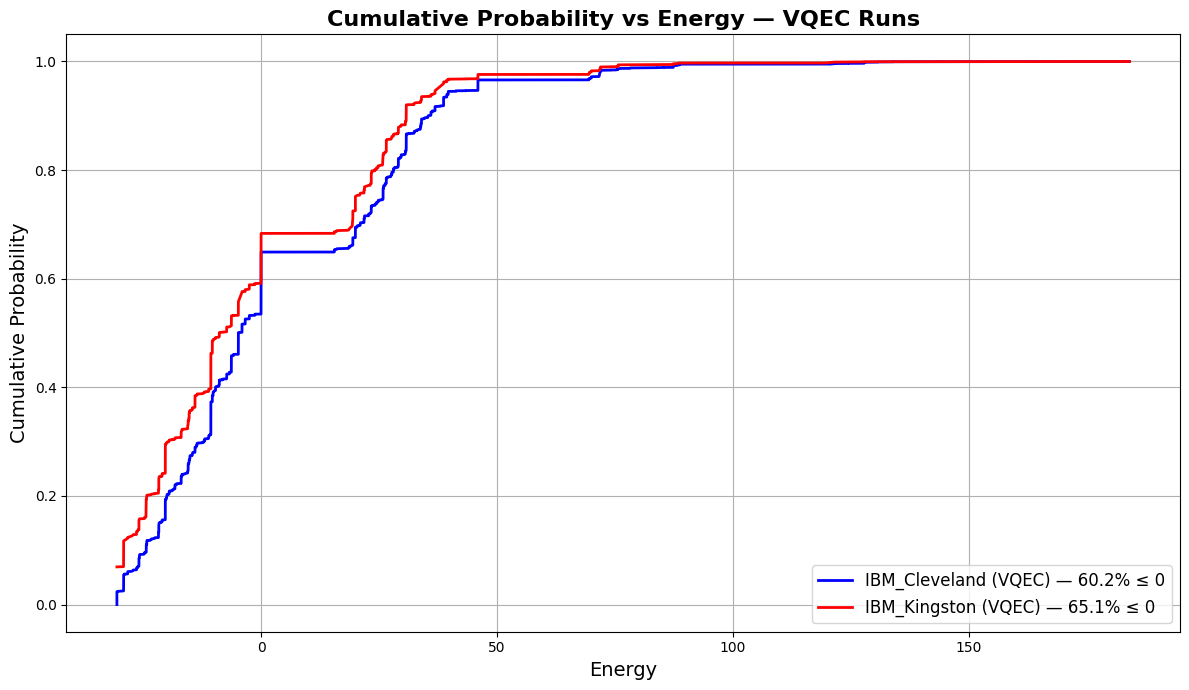

In [72]:
plt.figure(figsize=(12, 7))

color_map = {
    "IBM_Cleveland (VQEC)": "blue",
    "IBM_Kingston (VQEC)": "red"
}

# --- Register the datasets under proper labels ---
all_data_vqec = {
    "IBM_Cleveland (VQEC)": ibm_cleveland_vqec,
    "IBM_Kingston (VQEC)": ibm_kingston_vqec
}

for label in ["IBM_Cleveland (VQEC)", "IBM_Kingston (VQEC)"]:
    data = all_data_vqec[label]
    energies = data["energies"]
    probs = data["probs"]

    sorted_turns = sorted(probs.keys(), key=lambda t: energies[t])
    energy_vals = [energies[t] for t in sorted_turns]
    prob_vals = [probs[t] for t in sorted_turns]
    cum_probs = np.cumsum(prob_vals)

    # Compute % mass below E = 0
    cum_below_zero = sum(p for e, p in zip(energy_vals, prob_vals) if e < 0)
    label_augmented = f"{label} — {cum_below_zero:.1%} ≤ 0"

    # Plot cumulative curve with updated label
    plt.plot(energy_vals, cum_probs, label=label_augmented, color=color_map[label], lw=2)

plt.xlabel("Energy", fontsize=14)
plt.ylabel("Cumulative Probability", fontsize=14)
plt.title("Cumulative Probability vs Energy — VQEC Runs", fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc="lower right")
plt.grid(True)
plt.tight_layout()

# Optional: Save to file
plt.savefig("vqec_cumulative_probability.jpeg", dpi=400)

plt.show()


# Optional table summary

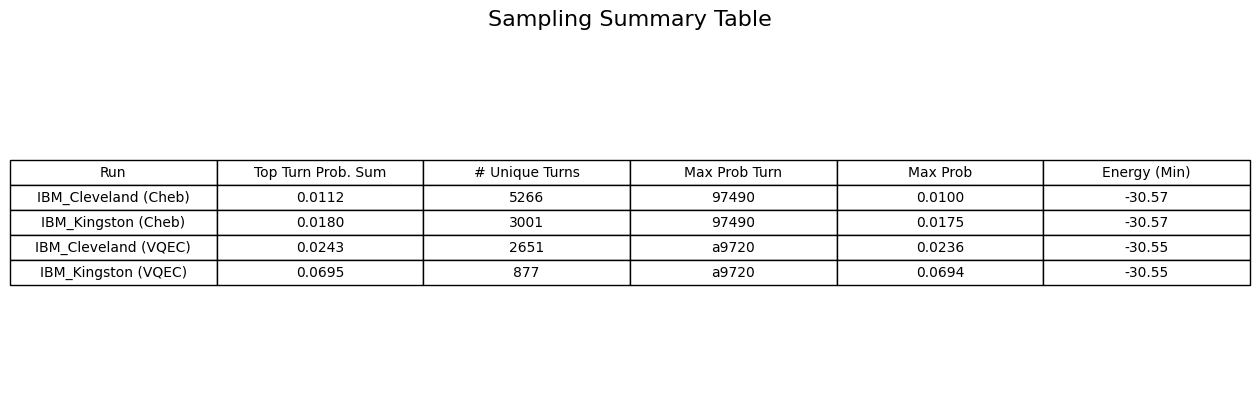

In [44]:
import pandas as pd

# Top classical turn sequences
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490',
                 '31a20', '31820', '2b580', '9a180', '5b580'}

# Build summary data
summary_rows = []

for label, d in all_data.items():
    energies = d["energies"]
    probs = d["probs"]

    # Top turn prob sum
    top_cls_prob_sum = sum(probs.get(t, 0) for t in top_cls_turns)

    # Unique turn count
    unique_turns = len(probs)

    # Max prob and corresponding turn
    max_prob_turn = max(probs, key=probs.get)
    max_prob = probs[max_prob_turn]

    # Minimum energy
    min_energy = min(energies.values())

    summary_rows.append({
        "Run": label,
        "Top Turn Prob. Sum": f"{top_cls_prob_sum:.4f}",
        "# Unique Turns": unique_turns,
        "Max Prob Turn": max_prob_turn,
        "Max Prob": f"{max_prob:.4f}",
        "Energy (Min)": f"{min_energy:.2f}"
    })

# Create DataFrame
df_summary = pd.DataFrame(summary_rows)

# Plot the table using matplotlib
fig, ax = plt.subplots(figsize=(16, 2 + len(df_summary) * 0.6))
ax.axis("off")
table = ax.table(cellText=df_summary.values,
                 colLabels=df_summary.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Sampling Summary Table", fontsize=16, pad=1)

# Optional: Save as image
# plt.savefig("sampling_summary_table.jpeg", dpi=300, bbox_inches='tight')

plt.show()
